# Team ADAstraPerAspera: Milestone P2

## Introduction

In this notebook, we present the data preprocessing along with the preliminary experiments aimed at answering the following central research question:

> **How do plaques influence the surrounding tissue?**

## Hardware
Throughout this notebook, we comment on the computational feasibility of the proposed methods. To support our claims, we report the execution time of the Python code blocks. For methodological consistency, we will disclose our hardware. All experiments reported in this work were performed on a single laptop machine. We used an Apple MacBook Pro equipped with the Apple M4 system‑on‑chip, and an integrated GPU. The machine has 16 GB of unified memory and a 512 GB solid‑state drive.

---

## Table of Contents

1. **Preliminary Steps**  
   * 1.a. [Imports](#imports)  
   * 1.b. [Loading environment variables and configutations](#loads)
   * 1.c. [Setting up paths to input and output data](#data_path)

2. **Dataset Preprocessing**  
   * 2.a. [Download, preprocess, and format Xenium data](#download)
   * 2.b. [Format the polygons around Aβ-plaque](#format)  
   * 2.c. [Compute cell-to-plaque distances](#compute)

3. **Exploratory Analysis**  
   * 3.a. [Descriptive statistics on gene expression](#desc)  
   * 3.b. [Expression signal in typical genes](#expr_sig)  
   * 3.c. [Anomaly detection framework](#anomaly)  
   * 3.d. [Expression signal in anomalous genes](#exp_anom)  

4. **Preliminary Analysis**  
   * 4.a. [Visualize the brain regions by plaque proximity](#viz_brain_regio)  
   * 4.b. [Gene expression by plaque distance](#gene_expr_dist)  

5. **Research Questions**  
   * 5.a. [How does PIG expression change in plaque proximity?](#rq1)  
      * 5.a.i. [Visual analysis](#rq1_visual)  
      * 5.a.ii. [Regression of PIG expression on plaque distance](#rq1_reg)  
      * 5.a.iii. [ANOVA-style analysis of PIG expression in different distance bins](#rq1_anova)  

   * 5.b. [How does cell type composition change in plaque proximity?](#rq2)  
      * 5.b.i. [Baseline analysis: how many cells are in each distance bin?](#rq2_baseline)  
      * 5.b.ii. [Cell clustering and analysis](#rq2_cell)  

   * 5.c. [Relationship between cell type composition, PIG expression, and plaque distance](#rq3)  
      * 5.c.i. [Cell composition at different distance bins](#rq3_cell_bin)  
      * 5.c.ii. [Correlation matrix between cell type composition and PIG expression](#rq3_corr)  
      * 5.c.iii. [Regression of PIG expression on cell type composition and plaque distance](#rq3_reg)  
      * 5.c.iv. [Visualization of PIG expression by cell type and distance bin](#rq3_viz)  

   * 5.d. [Inferring plaque distance from gene expression](#rq4)  
      * 5.d.i. [Predictive model benchmarking, explainability, and diagnostics](#rq4_pred)  


## 1. **Preliminary Steps**
<a id="imports"></a>  
   ### 1.a. Imports  
   - The imports include standard library modules, third-party libraries, and local modules.  
   - To ensure all third-party libraries are installed, please follow the installation instructions in `docs/setup.md`.

In [1]:
# Standard Library Imports
import os
import warnings

from dotenv import load_dotenv
import geopandas as gpd
import yaml

# Local Module Imports
from src.scripts.analysis import predictive_models as pm
from src.scripts.analysis.regression_analysis import (
    compute_gene_spatial_stats,
    
)
from src.scripts.preprocessing.geometry import (
    compute_cell_to_plaque_distances,
)
from src.scripts.preprocessing.orchestrators import (
    preprocess_cells_and_expression,
    preprocess_plaques,
)
from src.scripts.preprocessing.partition import (
    compute_pigs_zscores,
    compute_weird_gene_scores,
    summarize_genes,
)

from src.scripts.preprocessing.spatial_trends import (
    assign_distance_bins,
    mean_expression_by_bin,
    sem_expression_by_bin,
)
from src.scripts.research_questions.RQ1 import (
    compute_genewise_categorical_anova,
    regress_expression_vs_distance,
    summarize_gene_stats,
    summarize_pig_expression_by_distance,
)
from src.scripts.research_questions.RQ2 import (
    analyze_leiden_spatial,
    analyze_plaque_distance,
)
from src.scripts.research_questions.RQ3 import (
    analyze_plaque_distance_effects,
    process_cell_annotations,
)
from src.scripts.research_questions.RQ4 import (
    run_gene_distance_modeling,
)
from src.scripts.visualization.interactive_plots import (
    interactive_comp_pig_regression,
    plot_gene_expression_by_distance_interactive
)
from src.scripts.visualization.plots import (
    plot_gene_distributions,
    plot_weird_gene_panels,
    plot_expression_heatmap,
    plot_gene_expression_by_distance,
    plot_top_genes_by_distance,
    plot_top_spatial_genes,
    plot_cell_to_plaque_map_visible,
    plot_gene_trends,
    plot_mean_heatmap,
    plot_cellular_comp_by_dist,
    plot_pig_comp_heatmap,
    plot_model_performance,
    plot_multi_gene_signature,
    plot_plaques,
    plot_pred_vs_true,
    plot_residual_figure,
    plot_residual_hist,
    plot_spatial_overlay,
    plot_spatial_residual_map,
    plot_top_gene_importances,
)
from src.utils.logging_utils import logger, log_runtime
import time

warnings.filterwarnings("ignore")

# for Jupyter Notebook TOC : automatic generation of contents
#!pip install jupyter_contrib_nbextensions
#!jupyter contrib nbextension install
#!jupyter nbextension enable toc2/main


_nb_start_time = time.time()


<a id="loads"></a>
### 1.b. Loading environment variables and configutations 

- Before running the cell below, please create a `.env` file in the root directory of the project and add the following variables:
```
BASE_XENIUM_DIR=your/path/to/xenium/data
```
- If successful, the output of the cell will be `True`.

In [2]:
load_dotenv()

True

- Next, we will load the names of:
    - Plaque-Induced Gene (PIG) columns
    - Metadata columns
    - Cell-to-plaque distance columns

In [3]:
# Get absolute path to this notebook's directory
root_dir = os.getcwd()
# Since the configs are part of the repository, this cell shouldn't be modified
config_path = os.path.join(root_dir, "configs/column_annotations.yaml")

# Load the contents of configs from YAML into Python dictionaries
with open(os.path.realpath(config_path)) as f:
    config_dict = yaml.safe_load(f)
    PIG_GENES = config_dict["PIG_GENES"]
    meta_cols = config_dict["meta_cols"]
    distance_cols = config_dict["distance_cols"]

<a id="data_path"></a>
### 1.c. Setting up paths to input and output data
- In the following cell, we will define:
    - The public URL to the Xenium dataset (do not modify)
        - For the Milestone P2, we will focus on the transgenic mouse with advanced Alzheimer's disease (AD) pathology at 17.9 months of age
        - In this snapshot, the Aβ-plaques are well-developed, cell composition and gene expression is the most impacted by the disease, simplifying the discovery of patterns within the data
    - The path to the folder to store the unzipped contents of the Xenium dataset (defined in the step 1.b)
    - The path to cell type annotations (do not modify)
    - The path to the folder to store some preprocessing results (can be modified)

In [4]:
# This is the public URL to Xenium dataset
url = "https://cf.10xgenomics.com/samples/xenium/1.4.0/Xenium_V1_FFPE_TgCRND8_17_9_months/Xenium_V1_FFPE_TgCRND8_17_9_months_outs.zip"
# The path to the folder with unzipped contents of the file downloaded from the link above
BASE_XENIUM_DIR = os.environ["BASE_XENIUM_DIR"]
# Internal path to files stored in this repository
PATH_TO_DATA_FOLDER = "src/data/Xenium_V1_FFPE_TgCRND8_17_9_months"
# Cell type annotations from our TA, Ms. Yu
PATH_TO_ANNOTATIONS = f"{PATH_TO_DATA_FOLDER}/Alzeimer_xenium_predicted_cell_types_with_ids.csv"
# Path to store some preprocessing results; by default this is a subfolder in the Xenium download path
output_dir = f"{BASE_XENIUM_DIR}/Xenium_V1_FFPE_TgCRND8_17_9_months_outs"

## 2. **Dataset Preprocessing** 
<a id="download"></a> 
### 2.a. Download, preprocess, and format Xenium data  
- The Python block below runs a comprehensive preprocessing pipeline `preprocess_cells_and_expression` covering:
    - Xenium's cell data
    - Xenium's gene expression data
- **Data Format**
    - The cell dataframe is constructed from Xenium's `cells.parquet` file which contains the following key columns:
        - `cell_id`: Unique identifier for each cell
        - `x_centroid`: x-coordinate of the cell centroid
        - `y_centroid`: y-coordinate of the cell centroid
        - `nucleus_area`: Area of the polygon approximating the cell nucleus
        - `cell_area`: Area of the polygon approximating the cell membrane contour
        - `transcript_counts`: the number of recorded transcripts for each of the 347 recorded genes in a given cell
    - The expression dataframe is assembled from Xenium's `cell_feature_matrix.h5` file.
        - This file contains 347 colmns, one for each of the recorded genes
- **Missing values**
    - The dataframe derived from `cells.parquet` and `cell_feature_matrix.h5` contains no missing values
    - The missing values were likely pre-handled by Xenium's dataset provider, 10x Genomics
- **Preprocessing pipeline**
    - The key preprocessing steps include:
        - Inner-joining cell and expression data on the `cell_id` column
        - Filter cells falling below the 5th percentile of either of the following quality-control (QC)metrics:
            - Total transcript count
            - Cell area
            - Nucleus area
            - Number of genes with at least 1 recorded transcript
        - In the current data snapshot (TgCRND8 mice at 17.9 months of age), the following thresholds were computed:
            - Minimum transcript count: 42
            - Minimum cell area: 66.75 µm²
            - Minimum nucleus area: 8.41 µm²
            - Minimum number of genes with at least 1 recorded transcript: 24
        - After filtering the cells falling short of either of the above thresholds, 53895 / 60829 cells (88.6%) were retained
- As part of normalization, we applied a $x \mapsto \log_e(x + 1)$ transformation on the transcript counts to obtain `combined_df_normalized` dataframe
    - Originally, we planned to use the median-of-ratios method to compute a per-cell normalization factor (i.e., the __size factor__)
    - In this setting, we have 1 row per cell and 1 column per gene
    - However, Xenium's gene expression matrix is quite sparse; in fact, every gene has a zero transcript count for at least one cell
    - This leads to zero geometric mean of transcript counts for every gene
    - As a result, every __size factor__ computed by the `PyDESeq2` library is `NaN`
    - Thus, we simply set all __size factor__ values to `1.0` and skip per-cell normalization
- The raw transcript counts are retained in the `filtered_combined_df` dataframe
- The whole preprocessing is feasible as it completes in under 1 minute
- We defer descriptive statistics on `filtered_combined_df` to the section 
    > 3. **Exploratory Analysis**   

In [5]:
filtered_combined_df, combined_df_normalized, gene_cols = preprocess_cells_and_expression(
    url, output_dir, PATH_TO_DATA_FOLDER
)



Dataset already downloaded in the output directory, skipping.

Loading the data...

Loading cells table from the provided path
Loaded 62268 cells with 10 columns
         cell_id  x_centroid  y_centroid  transcript_counts  \
0  b'aaabiggh-1'  831.785336  755.803772                554   
1  b'aaacfoel-1'  821.733453  768.910446                291   
2  b'aaaeefil-1'  831.932053  780.367651                220   
3  b'aaaehidd-1'  853.614108  774.764157               1029   
4  b'aaagcbkg-1'  821.639603  799.171515                453   

   control_probe_counts  control_codeword_counts  unassigned_codeword_counts  \
0                     0                        0                           0   
1                     0                        0                           0   
2                     1                        0                           0   
3                     0                        0                           0   
4                     0                        0         

<a id="format"></a>
### 2.b. Format the polygons around Aβ-plaque  

#### Plaque Identification Pipeline
- The plaque polygons were defined by broadly following the approach in [Xenium's application note](https://pages.10xgenomics.com/rs/446-PBO-704/images/10x_LIT000210_App-Note_Xenium-In-Situ_Letter_Digital.pdf)
##### Raw data format

- In the Xenium Alzheimer Disease experiment, the Aβ plaques were stained with antibodies and later visualized with immunofluorescence (IF) microscopy.
- As a result, 10X Genomics provides `Xenium_V1_FFPE_TgCRND8_17_9_months_if_image.ome.tif` file with the IF data.
- This file contains two channels called `slice:1` and `slice:3`.
- `slice:1` contains coarse, unevenly spaced groups of bright pixels that represent the amyloid beta plaques.
- `slice:3` contains small and evenly spaced bright pixels that represent the nuclei of the cells.
- To identify the plaques, we restricted the analysis only to the `slice:1` channel.

##### Data labeling

- We produced 11 data points carrying rectangles around plaque-free regions (negative samples).
- Similarly, we labeled 9 data points with hand-drawn polygons around plaques (positive samples).
- We then used the object classifier from [QuPath](https://www.nature.com/articles/s41598-017-17204-5), employing the labeled points for training.
- We selected the default implementation of the random trees based classifier which tends to work better with the limited amount of training data.
- We then used the classifier to identify the plaques in the `slice:1` channel.
- The resulting objects (along with the ground truth labels used to train the classifier) are stored in `src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/Xenium_V1_FFPE_TgCRND8_17_9_months_if_image.qpdata`
- Only the predicted plaque polygons are exported to `src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/qupath_plaque_polygons.geojson`
- However, these coordinates are mismatched from the morphology coordinate space.
- And morphology coordinate space hosting all the cell coordinates loaded in the previous cells.
- Thus, we need to align the obtained plaque polygons to the morphology image.

##### Aligning the IF image to the morphology image

- To align IF image to the morphology space, we produced 26 keypoint pairs around important anatomical landmarks.
- These keypoints constitute a map between the two images.
- In other words, each pair contains closely visually aligned points on the IF image and the morphology image.
- These keypoints are stored in `src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/image_keypoints.csv`
- To reiterate, this file provides matched 2D control points relating `Xenium_V1_FFPE_TgCRND8_17_9_months_if_image.ome.tif` and `morphology_focus.ome.tif`
- The CSV columns of this file are:
- `fixedX`, `fixedY`: coordinates in the fixed/reference image, which is the morphology image.
- `alignmentX`, `alignmentY`: coordinates in the other image to be aligned, which is the IF image in our case.
- Next, we set up a transformation function that maps the keypoints from the IF image as closely as possible on average to their corresponding counterparts in the morphology image. This transformation is inferred by minimizing the following loss function:

$$
\mathcal{L}(\theta) = \frac{1}{N} \sum_{i=1}^{N} \left\| T_\theta(\mathbf{p}^{(i)}_{\text{IF}}) - \mathbf{p}^{(i)}_{\text{morph}} \right\|_2^2
$$

where:
- $T_\theta$ is the estimated transformation (we evaluated a `SimilarityTransform` and an `AffineTransform`),
- $\mathbf{p}^{(i)}_{\text{IF}} = (x^{(i)}_{\text{IF}}, y^{(i)}_{\text{IF}})$ are keypoints in the IF image,
- $\mathbf{p}^{(i)}_{\text{morph}} = (x^{(i)}_{\text{morph}}, y^{(i)}_{\text{morph}})$ are corresponding keypoints in the morphology image,
- and $N$ is the total number of matched keypoints ($N = 26$ in our case).  

- Namely, these key points were used to train a `SimilarityTransform` (RANSAC) model (which proved to perform better than an `AffineTransform`), resulting in a root mean squared error of 15.213 pixels or 15.213 * 0.2125 µm = 3.231 µm (microns), which is considered acceptable for our purposes.
- Note that in the above calculation, we are using the size of the pixel of 0.2125 µm as given by the 10x Genomics [documentation](https://kb.10xgenomics.com/s/article/11636252598925-What-are-the-Xenium-image-scale-factors).

- To repeat this analysis, run the following simple command below:

```bash
# Run from the root directory of the project
export PYTHONPATH="$PWD/src"
python -m scripts.plaque_alignment.cli --config configs/plaque_alignment.yaml
```
##### Transforming the plaque polygons

- Next, we applied the learned transformation to the plaque polygons.
- As a result, we obtained 1938 exterior polygons surrounding the plaques.
- The transformed plaque polygons which are stored in `src/data/Xenium_V1_FFPE_TgCRND8_17_9_months/plaque_polygons.csv`
- Importing these transformed polygons into the Xenium Explorer reveals close visual alignment with the morphology image, as visible in **Figure 1** below:

![Figure 1 — Formatted Xenium UI Polygons](src/data/figures/Formatted_Xenium_UI_Polygons.png)

#### Further preprocessing

- Next, we apply additional preprocessing steps:
    - Every polygon around a plaque is optionally closed and converted to a `shapely.geometry.Polygon` instance.
    - Namely, we coerce every plaque outline into a valid polygon, which is a planar surface bounded by one exterior LinearRing and zero or more interior LinearRings (holes). 
    -Rings must be closed and simple; if rings cross, the polygon is invalid as per [Shapely documentation](https://shapely.readthedocs.io/en/2.0.6/reference/shapely.Polygon.html)
    - Whenever feasible, we replace every non-convex polygon with a convex hull encompassing its interior.
    - Finally, we apply plaque filtering as outlined below.

**Objects and notation.**  
- Let $\mathcal{P}=\{P_1,\dots,P_n\}$ be the set of candidate plaques, each $P_i\subset\mathbb{R}^2$ a polygonal region.  
- Let $B\subset\mathbb{R}^2$ be the hand-drawn brain boundary polygon.  
- Let $A_i$ denote the polygon's area given by $\mu(P_i)$.

1. **No mutual intersections.** For all distinct $i,j\in\{1,\dots,n\}$,
   $$
   P_i\cap P_j=\varnothing.
   $$

2. **Each plaque touches the brain boundary.** For all $i$,
   $$
   P_i\cap B\neq\varnothing.
   $$

- Let us denote those plaques which satisfy the two criteria above as $\mathcal{P}^{\mathrm{valid}}$. 
- In our setup, the set $\mathcal{P}^{\mathrm{valid}}$ contains 1,828 plaques (out of 1,938 candidate plaques produces by QuPath software).
- This set will be further filtered by cutting off the plaques with areas below the 5th percentile.  
- Namely, we compute the empirical 5th percentile of areas over $\mathcal{P}^{\mathrm{valid}}$,
$$
t
\;:=\;
\operatorname{Quantile}_{0.05}\bigl(\{\,A_i:\;P_i\in\mathcal{P}^{\mathrm{valid}}\,\}\bigr).
$$

- Finally, we keep only those plaques whose area is no less than the threshold $t$:
$$
\mathcal{P}^{\mathrm{valid\&filtered}}
\;:=\;
\bigl\{\,P_i\in\mathcal{P}^{\mathrm{valid}}:\ A_i\ge t\,\bigr\}.
$$
- The resulting set of plaques, $\mathcal{P}^{\mathrm{valid\&filtered}}$, is bound to the `plaques_poly` Pandas dataframe.
- After applying the area cutoff, we kept 1,736 out of 1,828 plaques (95.0%).
- A visualization of the final set of closed, filtered, and mostly convex plaques is shown in the output of the following cell.
    - We can confirm that out of all plaques in the final set, only 25 are non-convex
    - All plaques are closed and are intersecting with the brain boundary
- All of the aforementioned steps, from plaque polygon inference with a random forest classifier to the final filtering, are feasible as they complete in under 10 minutes



Loading the plaque data...


Loading the brain polygon...

plaques_long: 161,308 vertices | plaques_poly: 1,938 polygons | brain polygon valid: True

Filtering the plaques...

{'n_final': 1828, 'polygons': 1828, 'multipolygons': 0, 'holes_present': 1, 'convex': 1803}
Kept after area cutoff: 1,736 out of 1,828
{'total': 1736, 'convex': 1711, 'non_convex': 25, 'holes_present': 1, 'mean_area': 133.9314068292565, 'in_brain': 1.0}


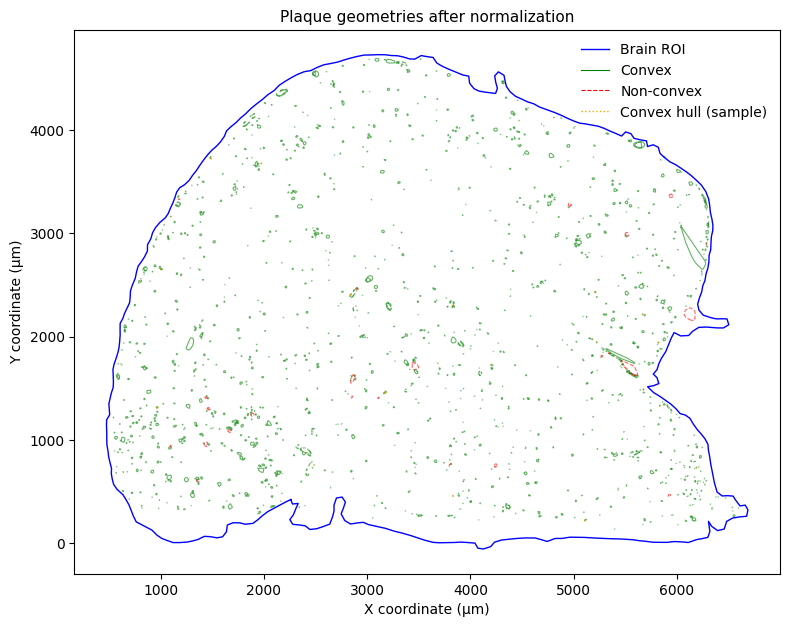

In [6]:
plaques_poly, brain_geom = preprocess_plaques(PATH_TO_DATA_FOLDER)
logger.info(
    {
        "total": len(plaques_poly),
        "convex": plaques_poly["is_convex"].sum(),
        "non_convex": (~plaques_poly["is_convex"]).sum(),
        "holes_present": plaques_poly["has_holes"].sum(),
        "mean_area": plaques_poly["area"].mean(),
        "in_brain": plaques_poly["in_brain"].mean(),
    }
)
ax = plot_plaques(
    plaques_poly,
    brain_geom=brain_geom if "brain_geom" in globals() else None,
    sample_hulls=20,
    seed=42,
    figsize=(8, 8),
)

<a id="compute"></a>
### 2.c. Compute cell-to-plaque distances  
- For each cell, we will compute the distance to the nearest preprocessedplaque and store it in the `distance_to_plaque` column of the `combined_df_normalized` dataframe
- The resulting distance between the cell centroid to the closest plaque boundary is measured in µm
- As outlined in the previous section, the preprocessed plaques are comprising the set $\mathcal{P}^{\mathrm{valid\&filtered}}$ of size $K$.
- Let the set of cells be $\{C_i\}_{i=1}^N$ with centroids $c_i$.
- For each cell, we will compute Euclidean distance $d_i$ from its centroid $c_i$ to the set of points comprising nearest plaque $P_{k^*(i)}$ as:
$$
d_i \;=\; \operatorname{dist}(c_i, P_{k^*(i)})
\;=\; \inf_{y \in P_{k^*(i)}} \|c_i - y\|_2,
\quad i=1,\dots,N.
$$
- In the expression above, the plaque $P_{k^*(i)}$ nearest to the cell $C_i$ is defined as:
$$
k^*(i) \;\in\; \arg\min_{1 \le k \le K}\; \operatorname{dist}(c_i, P_k).
$$
- As a result of the above procedure, no cells have missing nearest plaque distance (see output of the following cell).
- Finally, we will use inner join on `cell_id` to merge the `distance_to_plaque` column into the `combined_df_normalized` dataframe.
- The computation is feasible as it completes in under 1 minute

In [7]:
cells_with_distances = compute_cell_to_plaque_distances(filtered_combined_df, plaques_poly)
combined_df_normalized = combined_df_normalized.merge(
    cells_with_distances[
        [
            "cell_id",
            "distance_to_plaque",
            "nearest_plaque_center_dist",
            "inside_any_plaque",
            "nearest_plaque_id",
            "nearest_plaque_area",
        ]
    ],
    on="cell_id",
    how="inner",
)
logger.info(
    f"Number of cells with missing nearest plaque distance: {combined_df_normalized['distance_to_plaque'].isna().sum()}"
)

Computing distances: 100%|██████████████████████████████████| 53895/53895 [00:11<00:00, 4654.13it/s]


{'cells': 53895, 'plaques_used': 1736}
Number of cells with missing nearest plaque distance: 0


## 3. **Exploratory Analysis**

- We explore the properties of the transcription count matrix $X \in \mathbb{R}^{N \times M}$ by computing descriptive per-gene summary statistics.
- The matrix has entries entries $x_{ig}$ (cell $i \in \{1,\dots,N\}$, $N=53895$, gene $g \in \{1,\dots,M\}$, $M=347$). 
- Here 1 sample (i.e., 1 row) is corresponding to 1 cell.
- Further, we highlight the typical vs. anomalous gene expression patterns.
- We propose a framework to rank genes based on their unusualness.
- This approach can be used for feature selection as planned for Milestone P3.

<a id="desc"></a>
### 3.a. Descriptive statistics on gene expression

- For each gene $g$, we compute the following summary statistics based on its sample vector $\mathbf{x}_g = (x_{1g},\dots,x_{Ng})^\top$

- **Mean**  
  $$\bar x_g \;=\; \frac{1}{N}\sum_{i=1}^{N} x_{ig}.$$

- **Sample Standard deviation**
  $$s_g \;=\; \sqrt{\frac{1}{N-1}\sum_{i=1}^{N} \big(x_{ig}-\bar x_g\big)^2}.$$

- **Median**  
  $$\tilde x_g \;=\; \operatorname{median}\{x_{1g},\dots,x_{N g}\}.$$

- **Median Absolute Deviation**  
  $$\operatorname{MAD}_g \;=\; \operatorname{median}_{1\le i\le N}\big|x_{ig}-\tilde x_g\big|.$$

- **Skewness (adjusted Fisher–Pearson, bias-corrected)**  
  $$\gamma_{1,g} \;=\; \frac{\sqrt{N(N-1)}}{\,N-2\,}\;\frac{m_{3,g}}{m_{2,g}^{3/2}}.$$

- **Kurtosis (excess, bias-corrected)**  
  $$\gamma_{2,g} \;=\; \frac{N-1}{(N-2)(N-3)}\left[\,(N+1)\frac{m_{4,g}}{m_{2,g}^2}\;-\;3(N-1)\right].$$

- **Nonzero fraction**  
  $$\pi^{(\neq 0)}_g \;=\; \frac{1}{N}\sum_{i=1}^N \mathbf{1}\{x_{ig}\neq 0\}.$$

- In the expressions above, $m_{l,g}$ is the $l$-th central moment of the gene $g$ given by:
$$
\begin{aligned}
m_{l,g} \;&=\; \frac{1}{N}\sum_{i=1}^{N}\big(x_{ig}-\bar x_g\big)^{l}
\end{aligned}
$$

##### Results & Discussion

- As a result of the above analysis, we can observe that most genes are sparse (318 out of 347 genes have zero median)
- All 347 genes have right-skewed transcript counts
- Finally, we can see that the fraction of cells with nonzero transcript count varies widely (from 0.002 to 0.989) among genes
    - This suggests that the zero counts must be carefully handled in future modeling.
    - Further, this may imply that the genes with a small nonzero fraction may be specific to some cell types. 
    - This analysis is deferred to Milestone P3.

In [8]:
# 1. Compute per-gene summary statistics on filtered cells

g = filtered_combined_df[gene_cols]
summary = summarize_genes(filtered_combined_df[gene_cols])

logger.info(f"Genes summarized: {len(summary):,}")
logger.info(f"Number of genes with zero median: {summary['median'].eq(0).sum()}")
logger.info(f"Number of right-skewed genes: {summary['skew'].gt(0).sum()}")
logger.info(f"Number of left-skewed genes: {summary['skew'].lt(0).sum()}")
logger.info(f"Minimum nonzero fraction: {summary['nonzero_frac'].min()}")
logger.info(f"Maximum nonzero fraction: {summary['nonzero_frac'].max()}")
display(summary.head(10))

Genes summarized: 347
Number of genes with zero median: 318
Number of right-skewed genes: 347
Number of left-skewed genes: 0
Minimum nonzero fraction: 0.0020595602560534373
Maximum nonzero fraction: 0.9886260320994527


,mean,std,median,mad,skew,kurtosis,nonzero_frac
gene,,,,,,,
2010300C02Rik,1.585305,2.872456,0.0,0.0,3.058556,13.541861,0.444512
Abca7,0.218239,0.548753,0.0,0.0,3.103318,11.923915,0.168012
Acsbg1,0.773337,1.290950,0.0,0.0,2.683205,10.821354,0.407626
Acta2,0.145524,0.805564,0.0,0.0,12.379254,220.505327,0.080620
Acvrl1,0.100492,0.431738,0.0,0.0,5.907066,45.775163,0.068726
Adamts2,0.131144,0.483848,0.0,0.0,5.436704,44.362929,0.092625
Adamtsl1,0.090936,0.351991,0.0,0.0,5.089143,38.896464,0.074961
Adgrl4,0.172799,0.658698,0.0,0.0,5.422771,38.116629,0.095519
Aldh1a2,0.092495,0.642704,0.0,0.0,11.472683,188.234378,0.037907


<a id="expr_sig"></a>
### 3.b. Expression signal in Plaque-Induced Genes

#### Summary

- We will now explore the distribution shape of the transcript counts for the 16 Plaque-Induced Genes (PIGs) outlined in the Xenium's Application Note.
- To that end, we will plot histograms with $B=50$ bins (normalized to integrate to $1$) as well as Gaussian Kernel Density Estimate (KDE) curves for PIGs.

#### Mathematical formulation

- We will denote the set of PIGs as $\mathrm{PIGs}$:
$$
\mathrm{PIGs}
= \{\text{Hexb}, \text{Cst3}, \text{Cd63}, \text{C4b}, \text{Ctsd}, \text{B2m}, \text{H2-K1}, \text{Apoe}, \text{Gfap}, \text{Nrep}, \text{Serpina3n}, \text{Cd74}, \text{Cxcl10}, \text{Vim}, \text{S100a6}, \text{Ifit3}\}.
$$
- For each gene $g \in \mathrm{PIGs}$, we have:  
    - $X_g=\{x_{ig}\}_{i=1}^{N}$ denoting the observed transcript counts.  
    - $X_g^{(+)}=\{x_{ig}\in X_g:\;x_{ig}>0\}$ denoting the positive values and $N_{g,+}=|X_g^{(+)}|$.

- **KDE sample selection (zero-inflation handling).**  
    - If we have more than $5$ positive observations, the KDE is fit only on the positive values; otherwise it uses all observed values.
    - In other words, zeros are excluded from the KDE when there are sufficiently many positive counts ($N_{g,+}>5$).
    - This prevents the spike at $0$ from dominating the density estimate.
  $$
  S_g \;=\;
  \begin{cases}
    X_g^{(+)} & \text{if } N_{g,+} > 5,\\[4pt]
    X_g       & \text{otherwise,}
  \end{cases}
  \qquad N^\ast = |S_g|.
  $$


- **Histogram (with $B=50$ bins).**  
    - We partition $[\min X_g,\max X_g]$ into bins $\{I_k\}_{k=1}^{B}$ of widths $\Delta_k=|I_k|$, and let $c_{gk}$ be the transcript count in bin $I_k$.  
    - Next, we normalize the heights of the bars to sum up to $1$.
    - As a result, we obtain the piecewise-constant density estimate:
  $$
  \hat f_{g}^{\text{hist}}(t) \;=\; \sum_{k=1}^{B} \frac{c_{gk}}{N\,\Delta_k}\,\mathbf{1}\{t\in I_k\}.
  $$

- **Gaussian KDE.**  
    - With the Gaussian kernel $\phi(u)=\frac{1}{\sqrt{2\pi}}\exp\!\left(-\tfrac{u^2}{2}\right)$ and bandwidth
    $$
    h_g \;=\; \hat\sigma_g\, (N^\ast)^{-1/5}
    $$
    - In the formula above, $\hat\sigma_g$ is the sample standard deviation and $N^\ast$ is the effective sample size for handling zero-inflation.

    - As a result, the KDE is given by:
    $$
  \hat f_g(t) \;=\; \frac{1}{N^\ast\,h_g}\sum_{x\in S_g}\phi\!\left(\frac{t-x}{h_g}\right).
  $$

  - In the plots, $\hat f_g$ is evaluated on a uniform grid with $400$ points.
  $$
  t_j \;=\; \min(X_g) \;+\; \frac{j-1}{399}\,\big(\max(X_g)-\min(X_g)\big),
  \qquad j=1,\dots,400.
  $$

##### Results & Discussion

- We can observe that the distribution has an elevated density near zero.
- Above zero, the support gradually drops off at higher transcript counts.
- However, different PIGs have a different rate of the density decay.
- Three PIGs (cd74, lfit3, and cxcl10) stand out since their density is the most concentrated at zero.

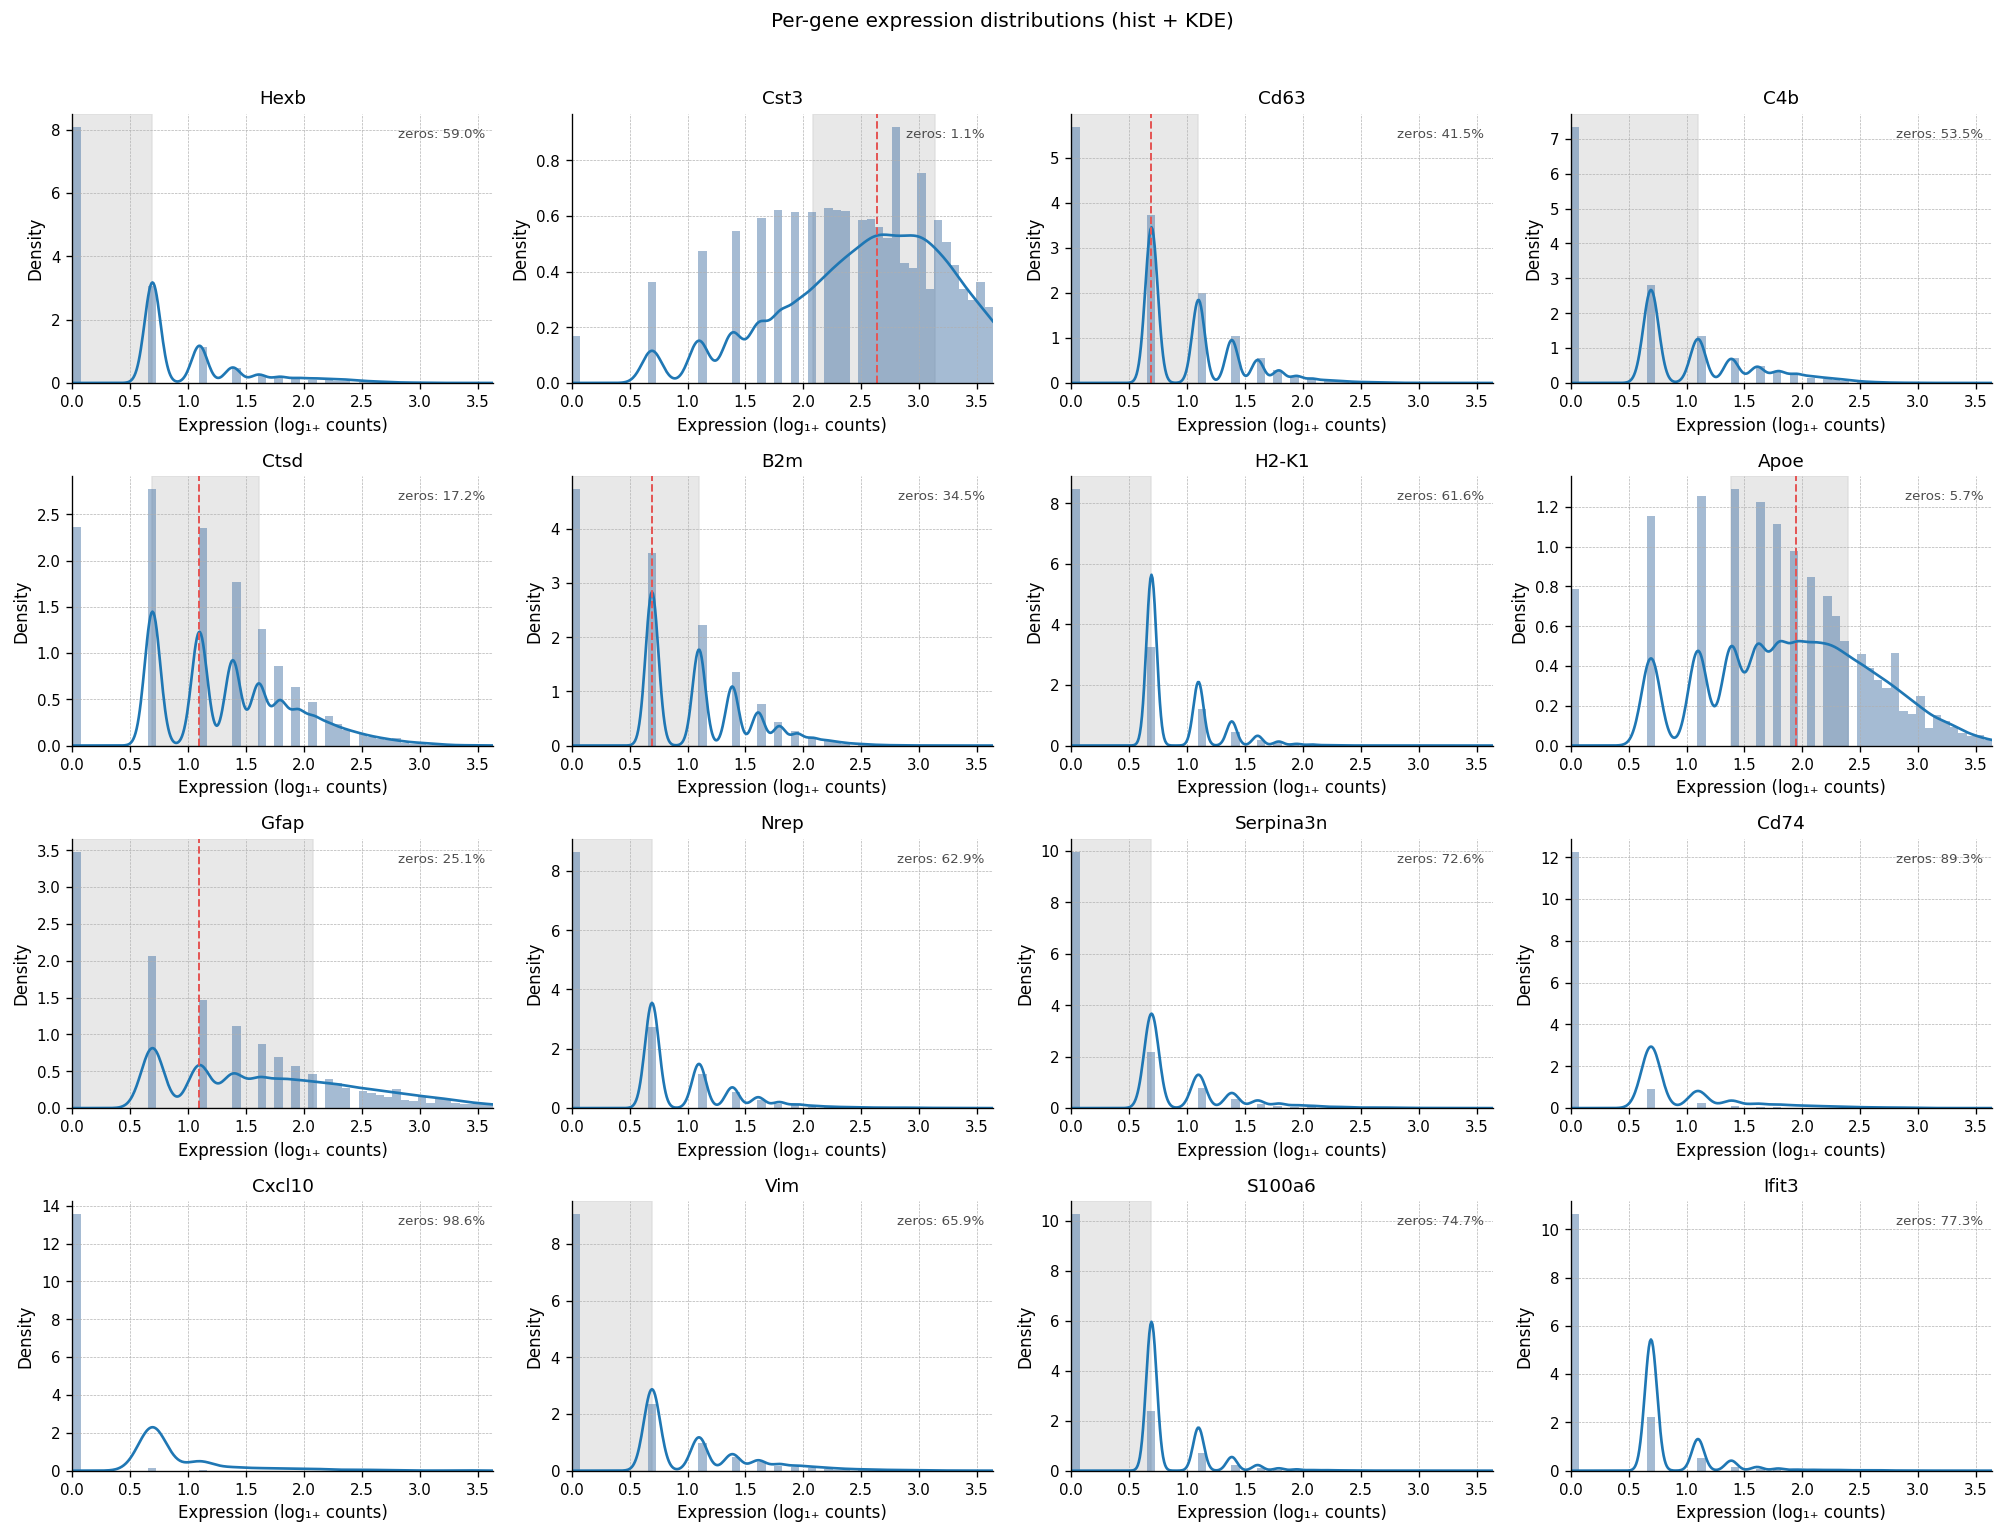

In [9]:
# 3. Plot the histogram + KDE for PIGs
pigs_z, info = compute_pigs_zscores(filtered_combined_df, gene_cols)
_ = plot_gene_distributions(filtered_combined_df, genes=info["present"])

<a id="anomaly"></a>
### 3.c. Anomaly detection framework

We quantify unusualness by combining zero-inflation, dispersion, and shape statistics into a composite score (ref. `compute_weird_gene_scores`). For each gene $g$ over $N$ cells:

- Zero inflation: $\text{zero\_frac}_g = 1 - \tfrac{N_{>0}(g)}{N}$
- Dispersion: $\mu_g = \mathbb{E}[X_g],\ \sigma_g = \sqrt{\mathrm{Var}(X_g)},\ \mathrm{cv}_g = \dfrac{\sigma_g}{\mu_g + \varepsilon}$
- Shape: 
    - Skewness $\gamma_{1g}$
    - Kurtosis $\gamma_{2g}$
- Tail ratio: $\mathrm{tail\_ratio}_g = \dfrac{q_{0.9}(X_g)+\varepsilon}{q_{0.1}(X_g)+\varepsilon}$

Standardize components (Z-scores), clip to $[-3, 3]$, and sum to obtain the composite score:
$$
\text{weird\_score}_g
= \sum_{k\in\{\text{zero\_frac},\ \text{cv},\ |\text{skew}|,\ \text{kurtosis},\ \text{tail\_ratio}\}}
\mathrm{clip}\bigl(Z_k(g), -3, 3\bigr).
$$

- Metrics computed for all 347 genes 
- Top-ranked genes by `weird_score` are visualized below.


In [10]:
# 4. For each gene, compute its unusualness based on zero-inflation, dispersion, and shape
S, Z = compute_weird_gene_scores(
    filtered_combined_df[gene_cols], clip_z=3.0, ddof_std=0, PIGs=info["present"]
)
logger.info(f"Genes evaluated: {len(S):,}")
logger.info("\nTop 20 by WEIRD SCORE")
display(S.head(20))
logger.info("\nTop 10 by ZERO FRAC")
display(
    S.sort_values("zero_frac", ascending=False).head(10)[
        ["isPIG", "zero_frac", "mean", "cv", "skew", "kurtosis"]
    ]
)
logger.info("\nTop 10 by |SKEW|")
display(
    S.reindex(S["skew"].abs().sort_values(ascending=False).head(10).index)[
        ["isPIG", "skew", "kurtosis", "zero_frac", "cv"]
    ]
)
logger.info("\nTop 10 by KURTOSIS")
display(
    S.sort_values("kurtosis", ascending=False).head(10)[
        ["isPIG", "kurtosis", "skew", "zero_frac", "cv"]
    ]
)

Genes evaluated: 347

Top 20 by WEIRD SCORE


,zero_frac,nonzero_frac,mean,std,cv,skew,kurtosis,q10,q90,tail_ratio,isPIG,weird_score
Tnf,0.997940,0.002060,0.002227,0.059955,26.927410,72.725511,9587.901700,0.0,0.0,1.0,False,9.428883
Chat,0.994860,0.005140,0.006494,0.123026,18.944303,61.862467,7137.261019,0.0,0.0,1.0,False,9.413116
Cxcl10,0.985861,0.014139,0.027776,0.391045,14.078404,36.332878,2017.429800,0.0,0.0,1.0,True,9.211140
Slc6a3,0.997532,0.002468,0.002987,0.067906,22.731506,32.874628,1507.098365,0.0,0.0,1.0,False,8.500838
Lcn2,0.997922,0.002078,0.002356,0.055948,23.742640,31.765245,1425.312232,0.0,0.0,1.0,False,8.379425
Th,0.985045,0.014955,0.028778,0.366274,12.727484,29.023833,1190.082336,0.0,0.0,1.0,False,7.666800
Cort,0.977864,0.022136,0.033194,0.342104,10.306151,28.137388,1253.944920,0.0,0.0,1.0,False,6.976647
Cd69,0.997792,0.002208,0.002208,0.046937,21.257920,21.211469,447.943040,0.0,0.0,1.0,False,6.150916
Nme8,0.995974,0.004026,0.004230,0.068249,16.132695,17.674773,362.083865,0.0,0.0,1.0,False,5.473340
Dkk2,0.993858,0.006142,0.006661,0.088131,13.230733,15.033796,269.558785,0.0,0.0,1.0,False,4.784686



Top 10 by ZERO FRAC


,isPIG,zero_frac,mean,cv,skew,kurtosis
Tnf,False,0.997940,0.002227,26.927410,72.725511,9587.901700
Lcn2,False,0.997922,0.002356,23.742640,31.765245,1425.312232
Cd69,False,0.997792,0.002208,21.257920,21.211469,447.943040
Slc6a3,False,0.997532,0.002987,22.731506,32.874628,1507.098365
Nme8,False,0.995974,0.004230,16.132695,17.674773,362.083865
Chat,False,0.994860,0.006494,18.944303,61.862467,7137.261019
Dkk2,False,0.993858,0.006661,13.230733,15.033796,269.558785
Ptx3,False,0.991595,0.008906,11.339809,14.000458,292.015996
Tgm1,False,0.990259,0.011615,11.265150,16.348204,400.986170
Crh,False,0.986882,0.021820,11.066071,17.465443,408.090353



Top 10 by |SKEW|


,isPIG,skew,kurtosis,zero_frac,cv
Tnf,False,72.725511,9587.901700,0.997940,26.927410
Chat,False,61.862467,7137.261019,0.994860,18.944303
Cxcl10,True,36.332878,2017.429800,0.985861,14.078404
Slc6a3,False,32.874628,1507.098365,0.997532,22.731506
Lcn2,False,31.765245,1425.312232,0.997922,23.742640
Th,False,29.023833,1190.082336,0.985045,12.727484
Cort,False,28.137388,1253.944920,0.977864,10.306151
Cd69,False,21.211469,447.943040,0.997792,21.257920
Nts,False,19.263740,497.488700,0.967993,9.714287
Ebf3,False,19.153784,646.190699,0.977939,9.008545



Top 10 by KURTOSIS


,isPIG,kurtosis,skew,zero_frac,cv
Tnf,False,9587.901700,72.725511,0.997940,26.927410
Chat,False,7137.261019,61.862467,0.994860,18.944303
Cxcl10,True,2017.429800,36.332878,0.985861,14.078404
Slc6a3,False,1507.098365,32.874628,0.997532,22.731506
Lcn2,False,1425.312232,31.765245,0.997922,23.742640
Cort,False,1253.944920,28.137388,0.977864,10.306151
Th,False,1190.082336,29.023833,0.985045,12.727484
Ebf3,False,646.190699,19.153784,0.977939,9.008545
Nts,False,497.488700,19.263740,0.967993,9.714287
Chodl,False,482.664371,18.214106,0.981909,9.861996


<a id="exp_anom"></a>
### 3.c. Anomaly detection framework

- We quantify unusualness of transcript counts by combining zero-inflation, dispersion, and shape statistics into a single score. 
- Namely, for each gene $g$ over $N$ cells, we compute five summary statistics:

    - Zero proportion: 
    $$
    \pi^{(= 0)}_g = 1 - \pi^{(\neq 0)}_g
    $$
    - Dispersion: 
    $$
    \mathrm{cv}_g = \dfrac{s_g}{\bar x_g + \varepsilon}
    $$
    - Shape: 
        - Skewness $\gamma_{1g}$
        - Kurtosis $\gamma_{2g}$
    - Tail ratio: $\mathrm{tail\_ratio}_g = \dfrac{q_{0.9}(X_g)+\varepsilon}{q_{0.1}(X_g)+\varepsilon}$

- We then z-normalize each of the five statistics, clip the results to $[-3, 3]$, and sum them to obtain the composite unusualness score for each gene $g$:
$$
\text{weird\_score}_g
= \sum_{k\in\{\text{zero\_frac},\ \text{cv},\ |\text{skew}|,\ \text{kurtosis},\ \text{tail\_ratio}\}}
\mathrm{clip}\bigl(Z_k(g), -3, 3\bigr).
$$

- The above calculation is performed on all 347 genes.
- The results of the following cell present:
    - Top 20 genes by the unusualness score $\text{weird\_score}_g$
    - Top 10 genes by the zero proportion $\pi^{(= 0)}_g$
    - Top 10 genes by the coefficient of variation $\mathrm{cv}_g$
    - Top 10 genes by the absolute value of the skewness $|\gamma_{1g}|$
    - Top 10 genes by the kurtosis $\gamma_{2g}$

##### Results & Discussion

- We find that among the 20 most unusual genes, there is only one PIG: Cxcl10
    - Looking at the diagnostic statistics above, we can see that Cxcl10 has a very high zero proportion $\pi^{(= 0)}_g =0.986$
    - This is also seen in the subsequent plots showing a flat, near-zero expression profile for Cxcl10 across all distance bins.

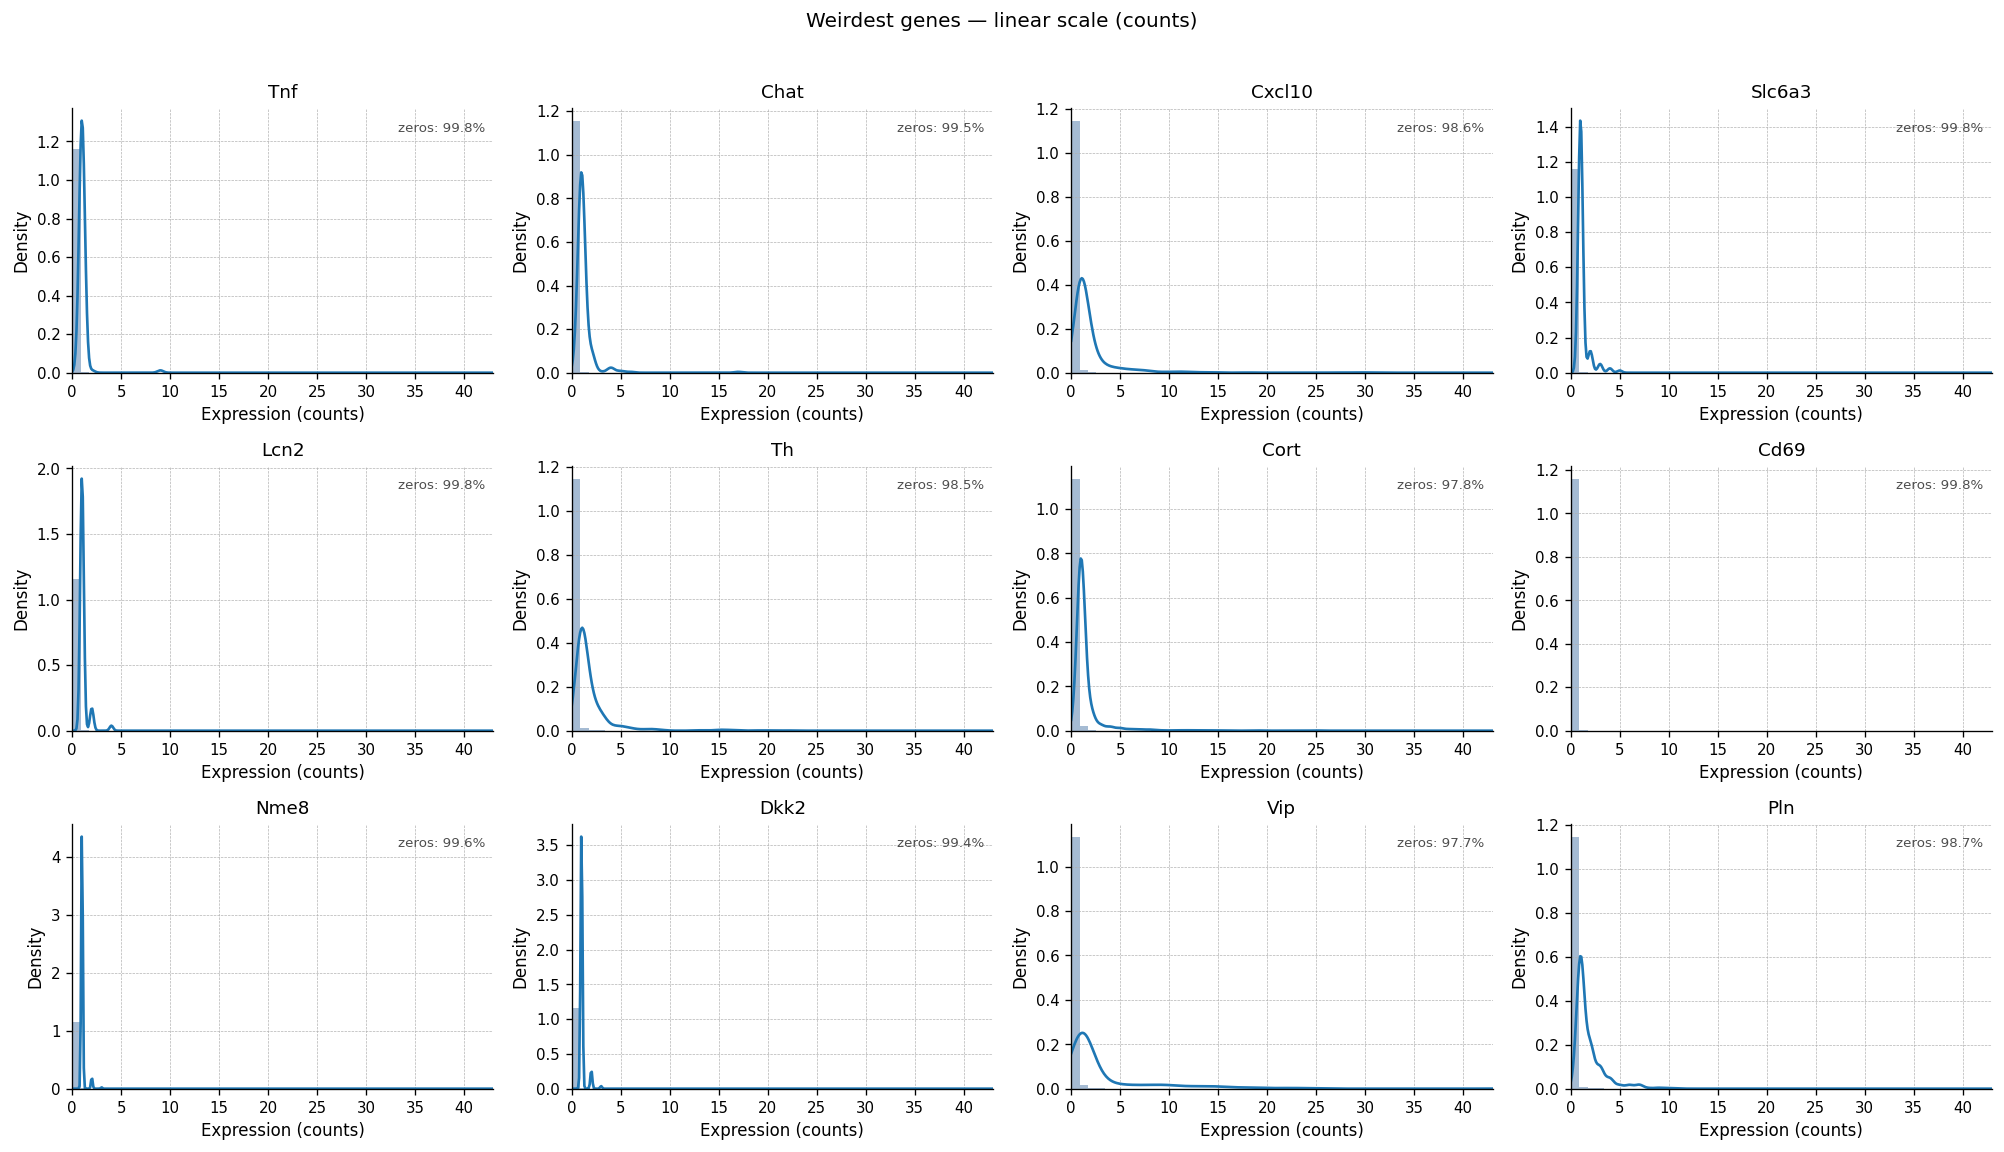

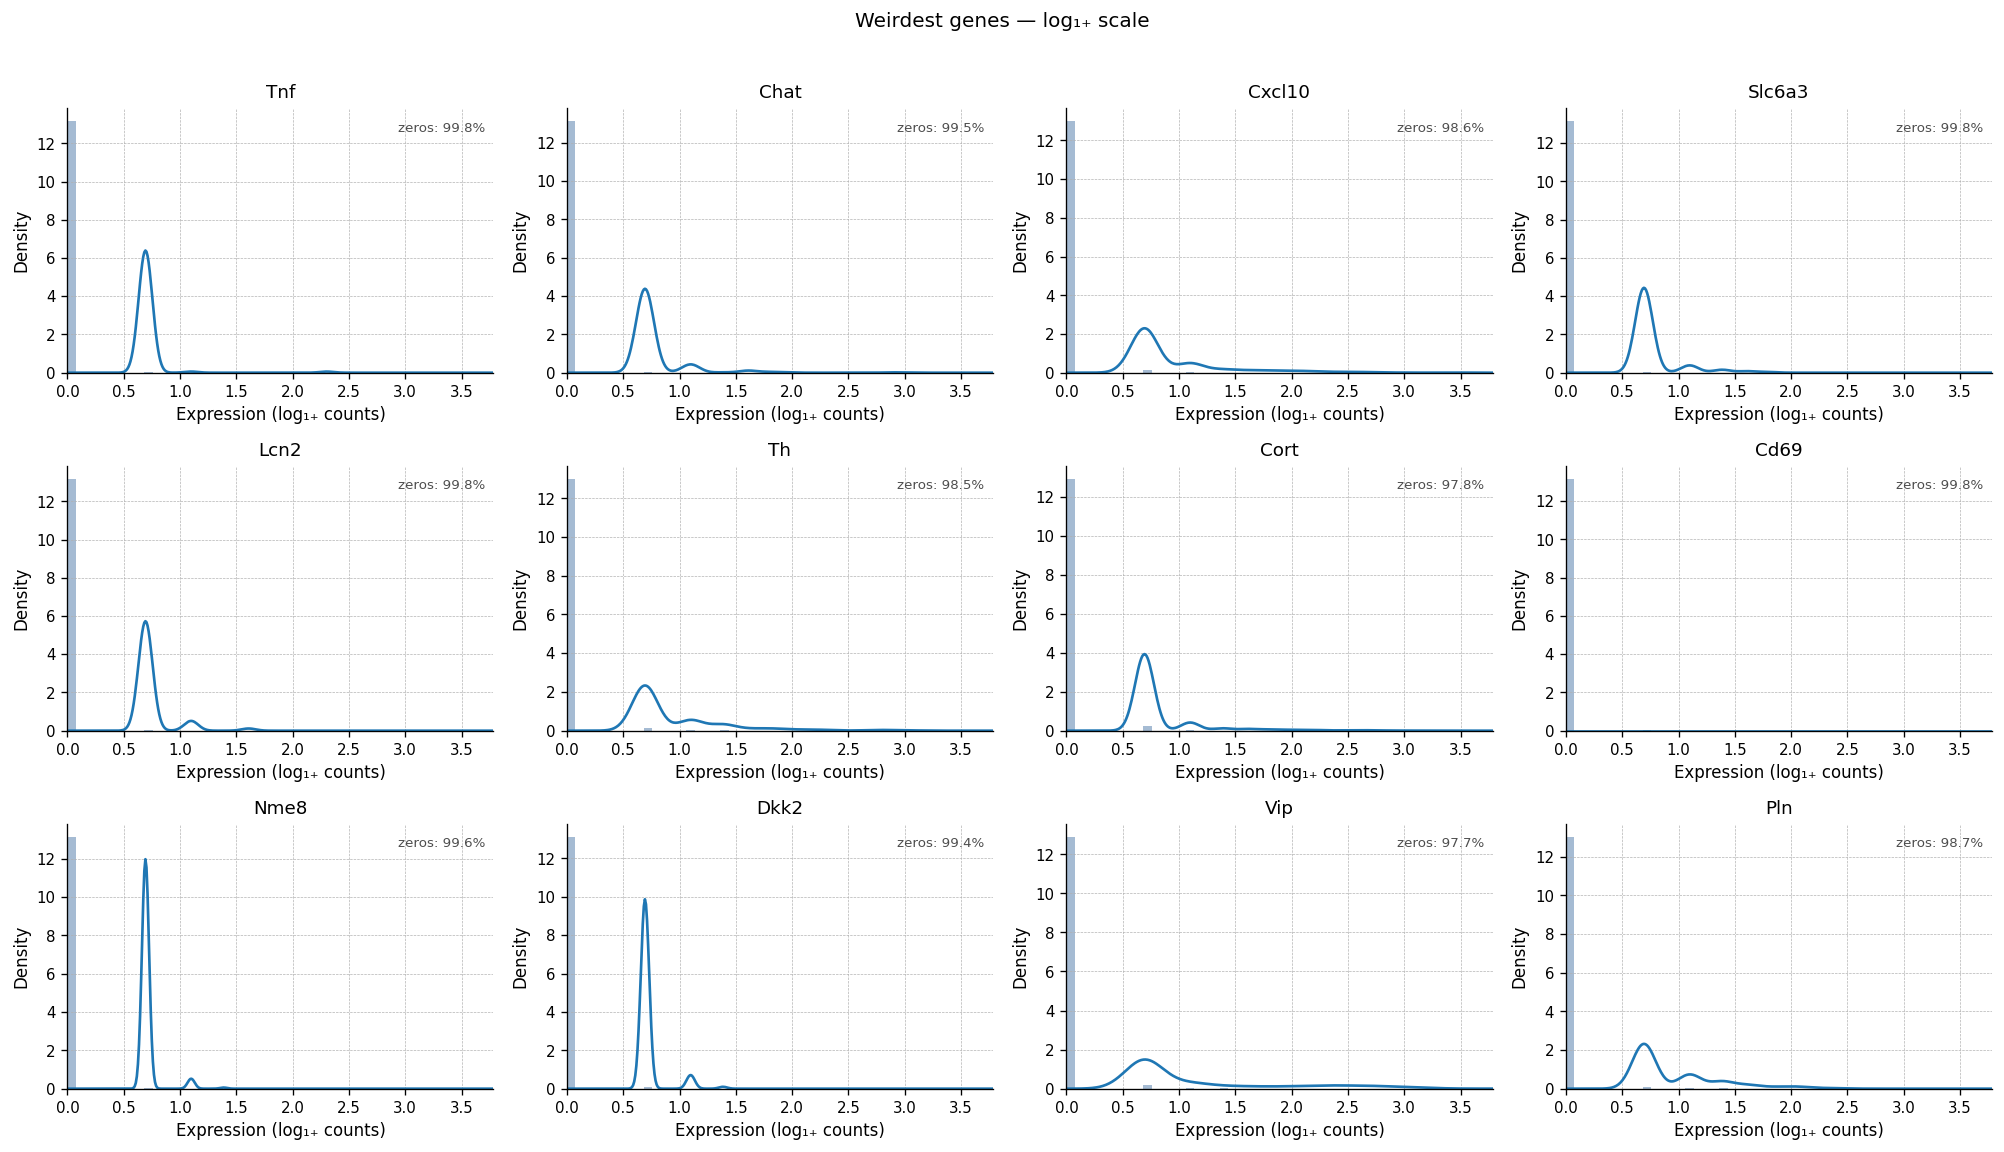

(<Figure size 2016x1152 with 12 Axes>, <Figure size 2016x1152 with 12 Axes>)

In [11]:
# 5. Plot the historgram and KDE for weirdest genes (linear and log1p)

genes_to_plot = S.head(12).index.tolist()
plot_weird_gene_panels(
    filtered_combined_df,
    genes_to_plot,
    bins=50,
    cols=4,
    show=True,
)

## 4. **Preliminary Analysis**

- In this section, we will perform a visualization of how the Aβ-plaques are segmenting the brain tissue by distance to the nearest plaque.
- Additionally, we will explore on a high-level how the proximity to the Aβ-plaques impacts expression of the known PIGs

<a id="viz_brain_regio"></a>
### 4.a. Visualize the brain regions by plaque proximity
- In the following code block, we highlight which brain regions are far away from Aβ-plaques and which are located nearby.
- We show this by overlaying the plaque polygons onto the morphology image.

##### Results & Discussion

- We can see that the maximum distance from any plaque is 457 µm; however, most of the brain tissue is located at most 200 µm from the nearest plaque.
- This is supported by the `combined_df_normalized` dataframe, which shows that 99.07% of all cells are within 200 µm from a plaque.

<a id="gene_expr_dist"></a>
### 4.b. Gene expression by plaque distance

#### Summary
- In this section, we investigate how the expression of the 347 recorded genes changes with distance to the nearest plaque.
- To this end, we bin the cells by distance to the nearest plaque and compute the mean expression within each bin.
- Namely, we quantile-bin `distance_to_plaque` into 6 bins.
- Further, we use a heatmap to highlight the genes with the largest difference in mean normalized transcript counts between the adjacent bins. 

#### Mathematical formulation

- We are working with the cells $i\in\{1,\dots,N\}$ and genes $g\in\mathcal{G}$, with $|\mathcal{G}|=347$.  
- Let $x_{ig}\ge 0$ denote the (log1p-normalized) transcript count of gene $g$ in cell $i$, and let $d_i\in\mathbb{R}_{\ge 0}$ be that cell’s distance to the nearest plaque.

##### Quantile binning of distances
- We fix the number of bins $m$ (in the following code block we reuse $m=5$ the same way it was done in all over the notebook).  
- Let $q_0<q_1<\dots<q_m$ be the empirical quantiles of the plaque-to-cell distances $\{d_i\}_{i=1}^N$.  
- We will work with the half-open bins formulated as follows
$$
B_b \;=\; [\,q_{b-1},\,q_b\,),\qquad b=1,\dots,m,
$$
- These bins define the bin assignment map which can be applied to any cell $i$:
$$
b(i)\;=\;\min\{\,b\in\{1,\dots,m\}\;:\; d_i\in B_b\,\}.
$$

##### Mean expression per distance bin
- For each gene $g$ and bin $b$, we compute the mean normalized transcript count via:
$$
\mu_{g b}
\;=\;
\frac{1}{|I_b|}
\sum_{i\in I_b} x_{ig},
\qquad
I_b \;=\;\{\, i:\; b(i)=b \,\},
$$

- These mean normalized transcript counts $\mu_{g b}$ are plotted across binned plaque distance to show the spatial trends in gene expression.

##### Ranking genes by spatial variation
- To examine which genes are most affected by the proximity of the Aβ-plaque, we define a spatial variation score $S_g$
- This score captures the variation across adjacent bins
$$
S_g
\;=\;
\sum_{b=2}^{m} \bigl|\mu_{g b}-\mu_{g,\,b-1}\bigr|,
\qquad g\in\mathcal{G}.
$$
- We then select the top 25 genes with the highest spatial variation for visualization.
- Next, to produce a heatmap of the spatial variation, we z-standardize each selected gene across bins:
$$
\tilde{\mu}_{g b}
\;=\;
\frac{\mu_{g b}-\bar{\mu}_g}{s_g},
\quad
\bar{\mu}_g=\frac{1}{m}\sum_{b=1}^{m}\mu_{g b},
\quad
s_g=\sqrt{\frac{1}{m-1}\sum_{b=1}^{m}(\mu_{g b}-\bar{\mu}_g)^2}.
$$

##### Results & Discussion

- The results show that among the 16 PIGs, Gfap shows the strongest spatial variation, as its expression quickly decays as we move away from the plaque.
    - This is supported by the Gfap's role as an intermediate filament protein found predominantly in astrocytes

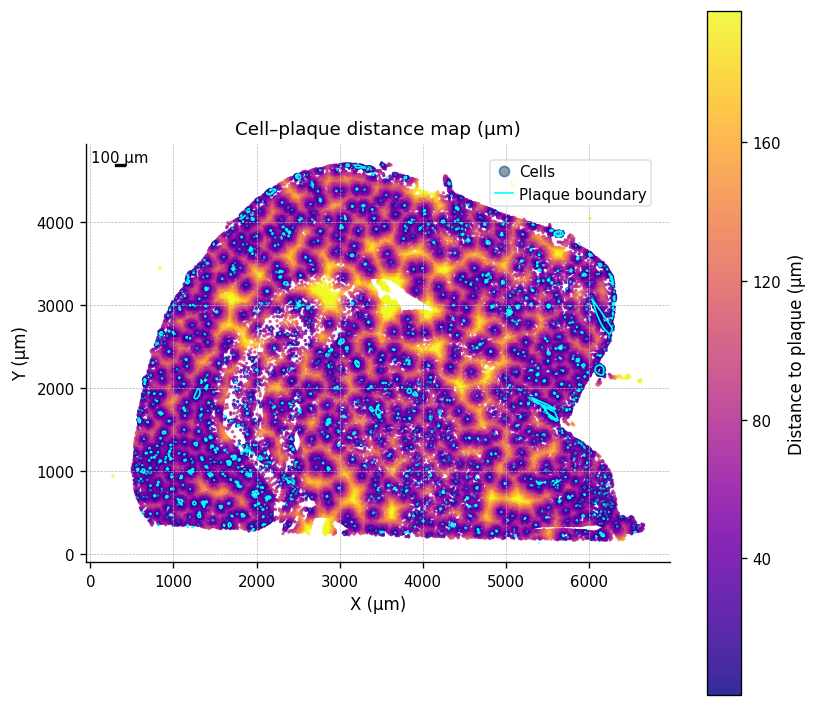

(<Figure size 840x720 with 2 Axes>,
 <Axes: title={'center': 'Cell–plaque distance map (µm)'}, xlabel='X (µm)', ylabel='Y (µm)'>)

In [12]:
plot_cell_to_plaque_map_visible(
    combined_df_normalized, gpd.GeoDataFrame({"geometry": plaques_poly["geometry"]})
)



Assigning 5 quantile bins by distance_to_plaque
Computing mean expression per bin
Computing SEM per bin


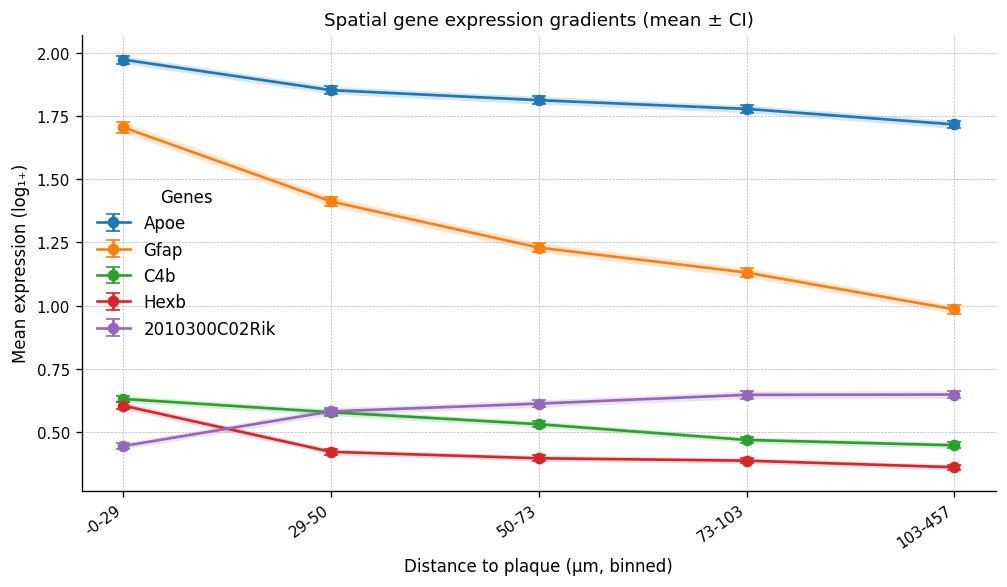

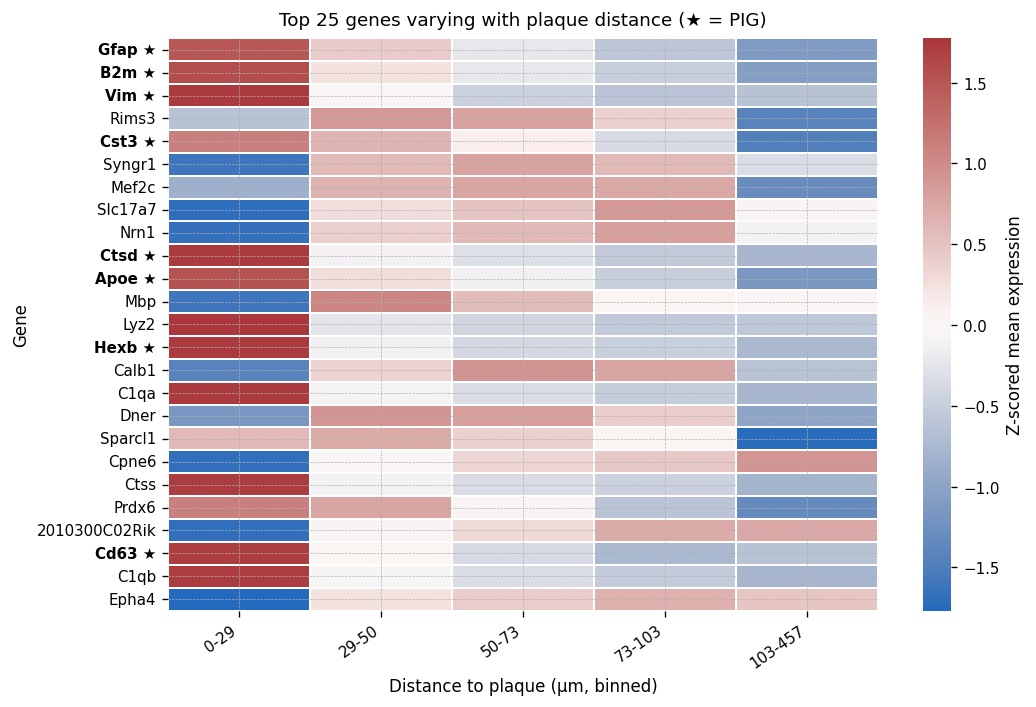

In [13]:
combined_binned = assign_distance_bins(combined_df_normalized, n_bins=5)
mean_expr = mean_expression_by_bin(combined_binned, gene_cols)
sem_expr = sem_expression_by_bin(combined_binned, gene_cols)
# Plot trends for known PIG genes
plot_gene_trends(
    mean_expr,
    ["Apoe", "Gfap", "C4b", "Hexb", "2010300C02Rik"],
    sem_expr=sem_expr,
)
# Visualize top genes with spatial gradients
plot_mean_heatmap(mean_expr, top_n=25, zscore=True, pig_genes=PIG_GENES)

### 4.c. Quantifying the expression vs. distance relationship

#### Summary

- We compute two key parameters for each gene: 
    - Spearman rank correlations between distance and the normalized transcript counts.
    - Ordinary least squares (OLS) slopes linking the normalized transcript count and the cell's distance to the nearest plaque.
- We use False Discovery Rate (FDR) correction for multiple testing.
    - This is a form of multiple-testing correction.
    - The correction is needed since we perform a separate regression analysis for each of the $M=347$ recorded genes.

#### Mathematical formulation

- Following the previously established conventions, let $\mathcal{G}$ be the set of recorded genes and let $N$ be the number of cells. 
- For each cell $i \in \{1,\dots,N\}$ we observe the plaque distance $d_i \in \mathbb{R}$ and, for each gene $g \in \mathcal{G}$, the normalized transcript count $x_{ig} \in \mathbb{R}$. 
- We denote $\mathbf{d} = (d_1,\dots,d_N)^\top$ and $\mathbf{x}_g = (x_{1g},\dots,x_{Ng})^\top$.


##### Spearman rank correlation
- Let $\mathrm{rank}(\cdot)$ return average ranks in the presence of ties. 
- We define the rank vectors
$$
\mathbf{u} = \mathrm{rank}(\mathbf{d}), \qquad \mathbf{v}_g = \mathrm{rank}(\mathbf{x}_g).
$$
- We then compute the Spearman correlation between the normalized transcript counts of each gene $g$ and the distance between its host cell and the nearest plaque:
$$
\rho_g \;=\; \mathrm{corr}(\mathbf{u}, \mathbf{v}_g)
\;=\; \frac{\sum_{i=1}^N (u_i-\bar u)(v_{ig}-\bar v_g)}
{\sqrt{\sum_{i=1}^N (u_i-\bar u)^2}\,\sqrt{\sum_{i=1}^N (v_{ig}-\bar v_g)^2}},
$$
- We use a two-sided $p$-value $p_g$ for testing the null hypothesis $H_0:\rho_g=0$.

##### OLS slope
- For each gene $g \in \mathcal{G}$, we fit the following simple linear model: 
$$
x_{ig} \;=\; \beta_{0g} + \beta_{1g}\,d_i + \varepsilon_{ig}, 
\qquad \varepsilon_{ig} \stackrel{\text{i.i.d.}}{\sim} \mathcal{N}(0,\sigma_g^2), 
\qquad i=1,\dots,N
$$
- The estimated slope (reported as `slope` in the `stats_df` Pandas dataframe) is found using the following closed-form expression:
$$
\hat\beta_{1g}
\;=\;
\frac{\sum_{i=1}^N (d_i-\bar d)(x_{ig}-\bar x_g)}{\sum_{i=1}^N (d_i-\bar d)^2}.
$$

##### Multiple testing correction
- We sort the computed Spearman $p$-values $\{p_g : g \in \mathcal{G}\}$:
$$
p_{(1)} \le p_{(2)} \le \cdots \le p_{(M)}, \quad \text{with the corresponding genes } g_{(1)},\dots,g_{(M)}.
$$
- We compute Benjamini–Hochberg-adjusted $q$-values:
$$
\tilde p_{(k)} \;=\; \min_{j \ge k} \left\{ \frac{M}{j}\,p_{(j)} \right\}, \qquad
q_{g_{(k)}} \;=\; \min\{1,\tilde p_{(k)}\}, \quad k=1,\dots,M.
$$
- Given the target false discovery level $\alpha \in (0,1)$, we classify gene $g$ to be significant if $q_g \le \alpha$.

##### Results & Discussion

- Similarly to the previous section, we find that the expression of Gfap has the strongest relationship with distance among all PIGs.
- This finding is supported with both the Spearman correlation and the OLS slope.
    - Overall, we find that the Spearman correlation tends to be larger than the OLS slope.
    - Potential reasons for this are as follows:
        - Spearman correlation is scale-invariant, while OLS slope is not.
        - Spearman rank correlation can capture non-linear relationships better than OLS slope.
        - Spearman correlation is less sensitive to outliers than OLS slope.


Computed spatial trends for 347 genes (FDR-corrected).


,gene,spearman_r,spearman_p,slope,fdr_pval
251,Ppp1r1b,0.085456,6.723845e-88,0.000950,6.305876e-87
0,2010300C02Rik,0.085246,1.783830e-87,0.001313,1.587151e-86
304,Spag16,0.084551,4.431051e-86,0.000581,3.843937e-85
75,Cpne6,0.081767,1.310929e-80,0.001480,1.109494e-79
187,Mdga1,0.080811,8.991452e-79,0.000496,7.255892e-78
...,...,...,...,...,...
27,C1qa,-0.155922,2.067421e-290,-0.001644,1.434790e-288
340,Vim,-0.170522,0.000000e+00,-0.001964,0.000000e+00
21,B2m,-0.185980,0.000000e+00,-0.002597,0.000000e+00
183,Lyz2,-0.189774,0.000000e+00,-0.001588,0.000000e+00


None of the top genes match provided PIG list. Check naming (e.g., symbol vs Ensembl).


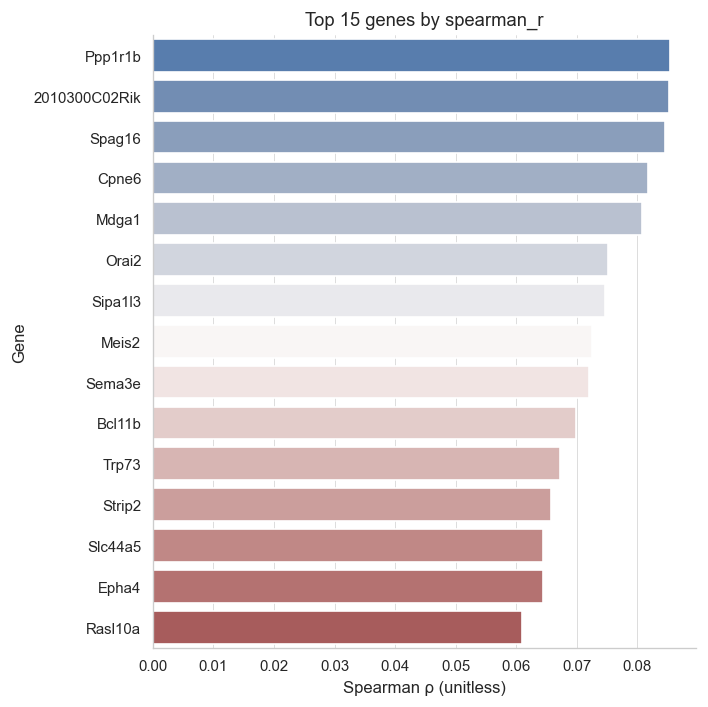

In [14]:
stats_df = compute_gene_spatial_stats(combined_df_normalized, gene_cols)
significant_genes = stats_df.query("fdr_pval < 0.05")
# filter for significant positive correlations
sig_pos = significant_genes.query("fdr_pval < 0.05")
display(sig_pos)
# visualize only significant ones
plot_top_spatial_genes(sig_pos, top_n=15, metric="spearman_r", pig_genes=PIG_GENES)

,gene,spearman_r,spearman_p,slope,fdr_pval,abs_spearman_r
50,Cd69,-0.009679,2.464187e-02,-0.000006,3.053832e-02,0.009679
344,Zfp366,-0.010247,1.736734e-02,-0.000037,2.167794e-02,0.010247
329,Tnf,-0.010553,1.428431e-02,-0.000007,1.795890e-02,0.010553
214,Ntng1,-0.010865,1.165494e-02,-0.000377,1.470641e-02,0.010865
309,Sst,-0.011104,9.943934e-03,-0.000106,1.259323e-02,0.011104
...,...,...,...,...,...,...
27,C1qa,-0.155922,2.067421e-290,-0.001644,1.434790e-288,0.155922
340,Vim,-0.170522,0.000000e+00,-0.001964,0.000000e+00,0.170522
21,B2m,-0.185980,0.000000e+00,-0.002597,0.000000e+00,0.185980
183,Lyz2,-0.189774,0.000000e+00,-0.001588,0.000000e+00,0.189774


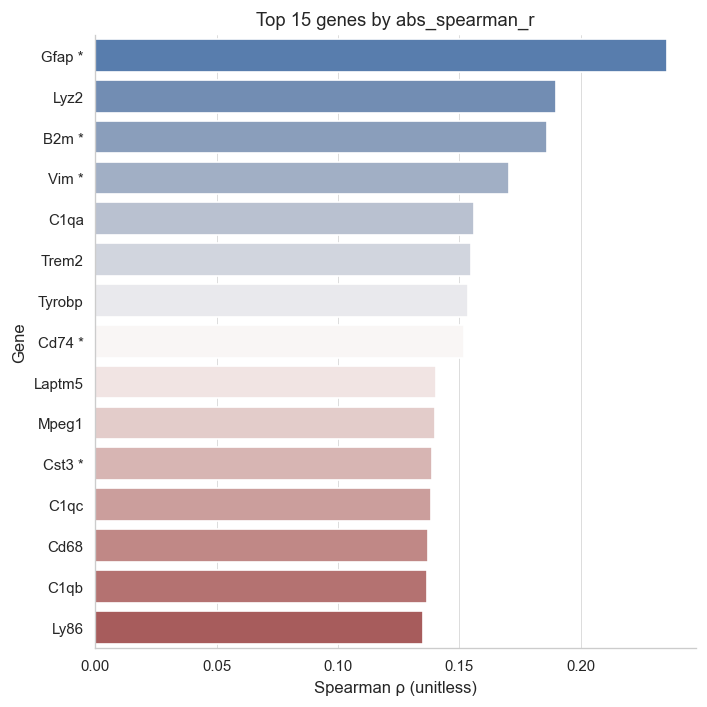

In [15]:
# filter for significant negative correlations
sig_neg = significant_genes.query("spearman_r < 0")
sig_neg["abs_spearman_r"] = sig_neg["spearman_r"].abs()
display(sig_neg)
plot_top_spatial_genes(sig_neg, top_n=15, metric="abs_spearman_r", pig_genes=PIG_GENES)

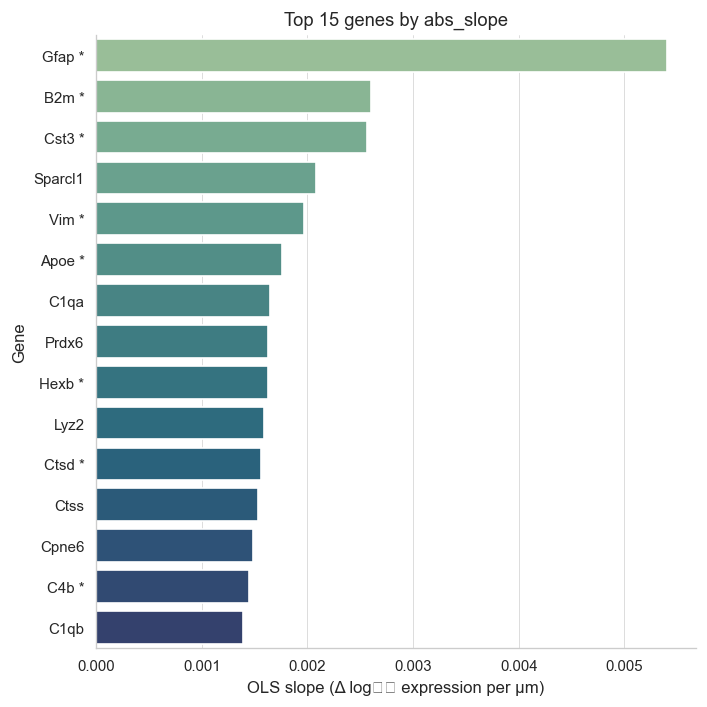

In [16]:
plot_top_spatial_genes(
    significant_genes.query("gene != 'total_counts'").assign(abs_slope=stats_df["slope"].abs()),
    metric="abs_slope",
    top_n=15,
    pig_genes=PIG_GENES
)

## 5. **Research Questions**
<a id="rq1"></a>
### 5.a. How does PIG expression change in plaque proximity?

<a id="rq1_visual"></a>
#### 5.a.i. Visual analysis

##### Summary
- As a preliminary step, we will visualize the change in the normalized transcript counts of the 16 PIGs across 5 bins of distance to the nearest plaque.
- This scoping down the preceding analysis which covered all 347 genes.
- Further, we compute per-bin mean as well as a Standard Error for the mean (SEM) for all 16 PIGs.

##### Mathematical formulation

- For any gene $g \in \mathcal{G}$ and any subset of cells $\mathcal{I}\subseteq\{1,\dots,N\}$ with size $n_{\mathcal{I}}$, we compute the sample mean and the sample variance of the normalized transcript counts $\{x_{ig}\}_{i\in\mathcal{I}}$ as
$$
\bar{x}_{g,\mathcal{I}} \;=\; \frac{1}{n_{\mathcal{I}}}\sum_{i\in\mathcal{I}} x_{ig},
\qquad
s_{g,\mathcal{I}}^{2} \;=\; \frac{1}{n_{\mathcal{I}}-1}\sum_{i\in\mathcal{I}}\bigl(x_{ig}-\bar{x}_{g,\mathcal{I}}\bigr)^{2}.
$$
- The standard error of the mean (SEM) for gene $g$ on this subset is then given by
$$
\mathrm{SEM}_{g,\mathcal{I}} \;=\; \frac{s_{g,\mathcal{I}}}{\sqrt{n_{\mathcal{I}}}}.
$$


In [17]:
summary_df, counts = summarize_pig_expression_by_distance(combined_df_normalized, PIG_GENES)
# SEM = standard error for mean
logger.info("Mean ± SEM of PIG expression by distance bin:")
display(summary_df.head(15))

# Also check how many cells fall into each bin
logger.info("\nCell counts per distance bin:")
display(counts)

Mean ± SEM of PIG expression by distance bin:


,distance_bin,gene,mean_expr,sem_expr
0,"(-0.001, 28.98]",Hexb,0.604277,0.007054
1,"(28.98, 50.315]",Hexb,0.421621,0.005651
2,"(50.315, 72.638]",Hexb,0.396212,0.005599
3,"(72.638, 102.91]",Hexb,0.386739,0.005453
4,"(102.91, 457.387]",Hexb,0.360818,0.005255
5,"(-0.001, 28.98]",Cst3,2.691040,0.007722
6,"(28.98, 50.315]",Cst3,2.629504,0.007517
7,"(50.315, 72.638]",Cst3,2.569555,0.007561
8,"(72.638, 102.91]",Cst3,2.510243,0.007606
9,"(102.91, 457.387]",Cst3,2.374462,0.007896



Cell counts per distance bin:


distance_bin
(-0.001, 28.98]      10779
(28.98, 50.315]      10779
(50.315, 72.638]     10779
(72.638, 102.91]     10779
(102.91, 457.387]    10779
Name: count, dtype: int64

- Visualization details: `plot_gene_expression_by_distance` draws per-gene mean ± SEM across ordered distance bins; `plot_expression_heatmap` summarizes the same information compactly. Both highlight consistent decreasing gradients for microglial (e.g., Hexb, Ctsd, Cst3, Apoe) and astrocytic (e.g., Gfap, Serpina3n, Vim) markers.

In [18]:
plot_gene_expression_by_distance_interactive(
    summary_df,
    pig_genes=PIG_GENES   # replace with your list
)

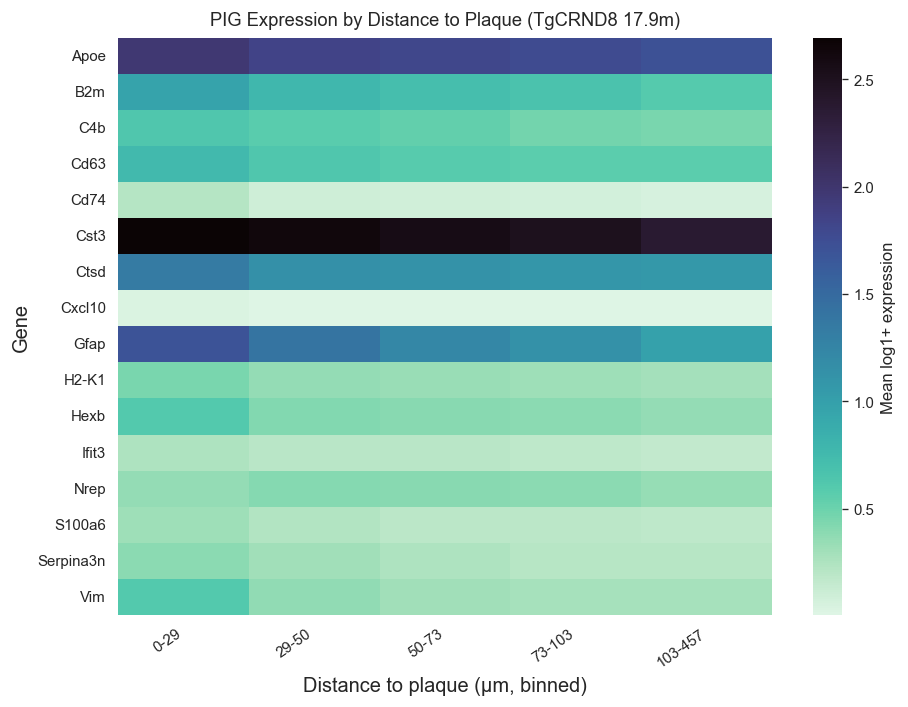

In [19]:
_ = plot_expression_heatmap(summary_df)

- Proximal plaques show elevated microglial (Hexb, Ctsd, Cst3, Apoe) and astrocytic (Gfap, Serpina3n, Vim) expression that fades with distance. Patterns are coherent across visualizations (errorbar panels and heatmap).

<a id="rq1_reg"></a>
#### 5.a.ii. Regression of PIG expression on plaque distance

##### Mathematical formulation

- For each $g \in \mathrm{PIGs}$, we fit an ordinary least squares (OLS) regression with an intercept:
$$
x_{ig} \;=\; \beta_{0g} + \beta_{1g}\,d_i + \varepsilon_{ig}, 
\qquad \varepsilon_{ig} \stackrel{\text{i.i.d.}}{\sim} \mathcal{N}(0,\sigma_g^2), 
\qquad i=1,\dots,N
$$
- Here, we have that:
    - $x_{ig}$ is the normalized transcript count in cell $i$ 
    - $d_i$ is the distance of cell $i$ to the nearest plaque in µm.

- We compute p-values associated with the null hypothesis $H_0:\ \beta_{1g}=0$ (no distance effect)$.
- As outlined in the previous section, we also perform multiple testing correction using the Benjamini–Hochberg FDR adjustment across the 16 PIGs.
- Since $x_{ig}$ are log-normalized counts, the slope $\beta_{1g}$ equals the change in log of transcript count per additional µm from the nearest plaque.
- The negative sign of the inferred coefficients ($\beta_{1g}<0$) implies higher gene expression around plaques.
- In other words, expression of PIGs decreases with distance. 
- Meanwhile, the intercept $\beta_{0g}$ equals the baseline log-expression at $d=0$, i.e., at the plaque surface.
- To transform the changes in log-expression to the original integer transcript count scale, we can use the fold-change formula:
- As we move $\Delta d$ microns away from the plaque, the fold-change in expected transcript count of gene $g$ is
$$
\text{Fold-change}_g(\Delta d) \;=\; \exp\!\big(\beta_{1g}\,\Delta d\big).
$$
- In relative terms, the corresponding percentage change in the integer transcript count is
$$
\%\Delta \;=\; 100\cdot\big[\exp(\beta_{1g}\,\Delta d)-1\big].
$$

##### Results & Discussion
- All 16 PIGs exhibit a statistically significant negative slope at 0.01 FDR level.
- However, the slopes vary significantly among PIGs, with the smallest and largest absolute values of slopes corresponding to Cxcl10 and Gfap, respectively.
- Gfap: 
    - $\beta_{1,\mathrm{Gfap}}\approx -5.41\times 10^{-3}$/µm.
    - Distance to halve expression:
    $$
    d_{1/2,g} \;=\; \frac{\ln 2}{|\beta_{1g}|} \;\approx\; \frac{0.693}{0.00541} \;\approx\; 128~\mu\mathrm{m}.
    $$
- Cxcl: 
    - $\beta_{1,\mathrm{Cxcl10}}\approx -1.57\times 10^{-4}$/µm.
    - Half-distance:
    $$
    d_{1/2,g}\approx \frac{0.693}{0.000157}\approx 4{,}415~\mu\mathrm{m}
    $$ 
    - This value exceeds the radius of the brain tissue, indicating that for Cxcl10, the spatial trend is very weak.



In [20]:
reg_df, proximal_genes = regress_expression_vs_distance(
    combined_df_normalized, PIG_GENES, logger=logger
)
logger.info("Continuous regression results (expression ~ distance):")
display(reg_df)

# Highlight top plaque-proximal genes (negative slope)
proximal_genes = reg_df[reg_df["slope"] < 0].sort_values("qval").head(10)
logger.info("\nTop plaque-proximal genes (negative slope, smallest q-values):")
display(proximal_genes)

Continuous regression results (expression ~ distance).
Computed 16 gene regressions.
Top plaque-proximal genes (negative slope, smallest q-values): 10 returned.
Continuous regression results (expression ~ distance):


,gene,slope,pval,qval
8,Gfap,-0.005408,0.000000e+00,0.000000e+00
5,B2m,-0.002597,0.000000e+00,0.000000e+00
1,Cst3,-0.002562,6.287627e-240,2.515051e-239
13,Vim,-0.001964,2.713979e-261,1.447455e-260
7,Apoe,-0.001763,1.218245e-109,1.949192e-109
0,Hexb,-0.001622,2.067871e-165,5.514323e-165
4,Ctsd,-0.001556,7.925067e-105,1.152737e-104
3,C4b,-0.001445,5.028431e-112,1.005686e-111
10,Serpina3n,-0.001202,6.635228e-139,1.516624e-138
11,Cd74,-0.001027,1.634044e-209,5.228941e-209



Top plaque-proximal genes (negative slope, smallest q-values):


,gene,slope,pval,qval
8,Gfap,-0.005408,0.000000e+00,0.000000e+00
5,B2m,-0.002597,0.000000e+00,0.000000e+00
13,Vim,-0.001964,2.713979e-261,1.447455e-260
1,Cst3,-0.002562,6.287627e-240,2.515051e-239
11,Cd74,-0.001027,1.634044e-209,5.228941e-209
0,Hexb,-0.001622,2.067871e-165,5.514323e-165
10,Serpina3n,-0.001202,6.635228e-139,1.516624e-138
3,C4b,-0.001445,5.028431e-112,1.005686e-111
14,S100a6,-0.000885,3.523692e-110,6.264341e-110
7,Apoe,-0.001763,1.218245e-109,1.949192e-109


Interpretation of $\beta_{1g}$: change in log-expression per additional $\mu\mathrm{m}$ from the nearest plaque.

- Direction: $\beta_{1g}<0$ implies plaque-proximal enrichment (expression decreases with distance). Canonical examples: Gfap, Cst3, Apoe, Hexb, Serpina3n, Vim.
- Magnitude: slopes $\approx -0.001$ to $-0.005$ per $\mu\mathrm{m}$ (consistent but small in absolute units). A $100\,\mu\mathrm{m}$ increase corresponds to $\sim 0.1$–$0.5$ drop in log expression.
- Weak or flat trends (e.g., Nrep, Ifit3, Cxcl10) suggest limited spatial patterning for those genes.


<a id="rq1_anov"></a>
#### 5.a.iii. ANOVA-style analysis of PIG expression in different distance bins

Model per gene $g$:
$$
y_{ig} = \alpha_{g0} + \sum_{k=2}^{K} \alpha_{gk}\,\mathbf{1}\{\text{distance\_bin}_i = k\} + \varepsilon_{ig},
$$
with a Type-II ANOVA test for the group effect $C(\text{distance\_bin})$.

- Evidence: ANOVA table computed for PIGs ("Categorical ANOVA results (expression ~ distance_bin)"). Significant bin effects align with continuous-model slopes for proximal-enriched genes.


- Display note: Full per-gene ANOVA tables are generated programmatically; the display cell previews the head for inspection. Use `plot_top_genes_by_distance` to inspect distributions for the most significant genes across bins.

In [21]:
anova_df = compute_genewise_categorical_anova(combined_binned, PIG_GENES)
logger.info("Categorical ANOVA results (expression ~ distance_bin):")
display(anova_df.head(10))

Categorical ANOVA results (expression ~ distance_bin):


,gene,anova_pval,qval
0,B2m,0.000000e+00,0.000000e+00
1,Gfap,0.000000e+00,0.000000e+00
2,Cd74,0.000000e+00,0.000000e+00
3,Vim,0.000000e+00,0.000000e+00
4,Hexb,1.111715e-238,3.557487e-238
5,Cst3,8.305159e-214,2.214709e-213
6,Serpina3n,6.228163e-205,1.423580e-204
7,Ctsd,5.412445e-203,1.082489e-202
8,S100a6,4.170606e-181,7.414411e-181
9,Cd63,2.009742e-152,3.215588e-152


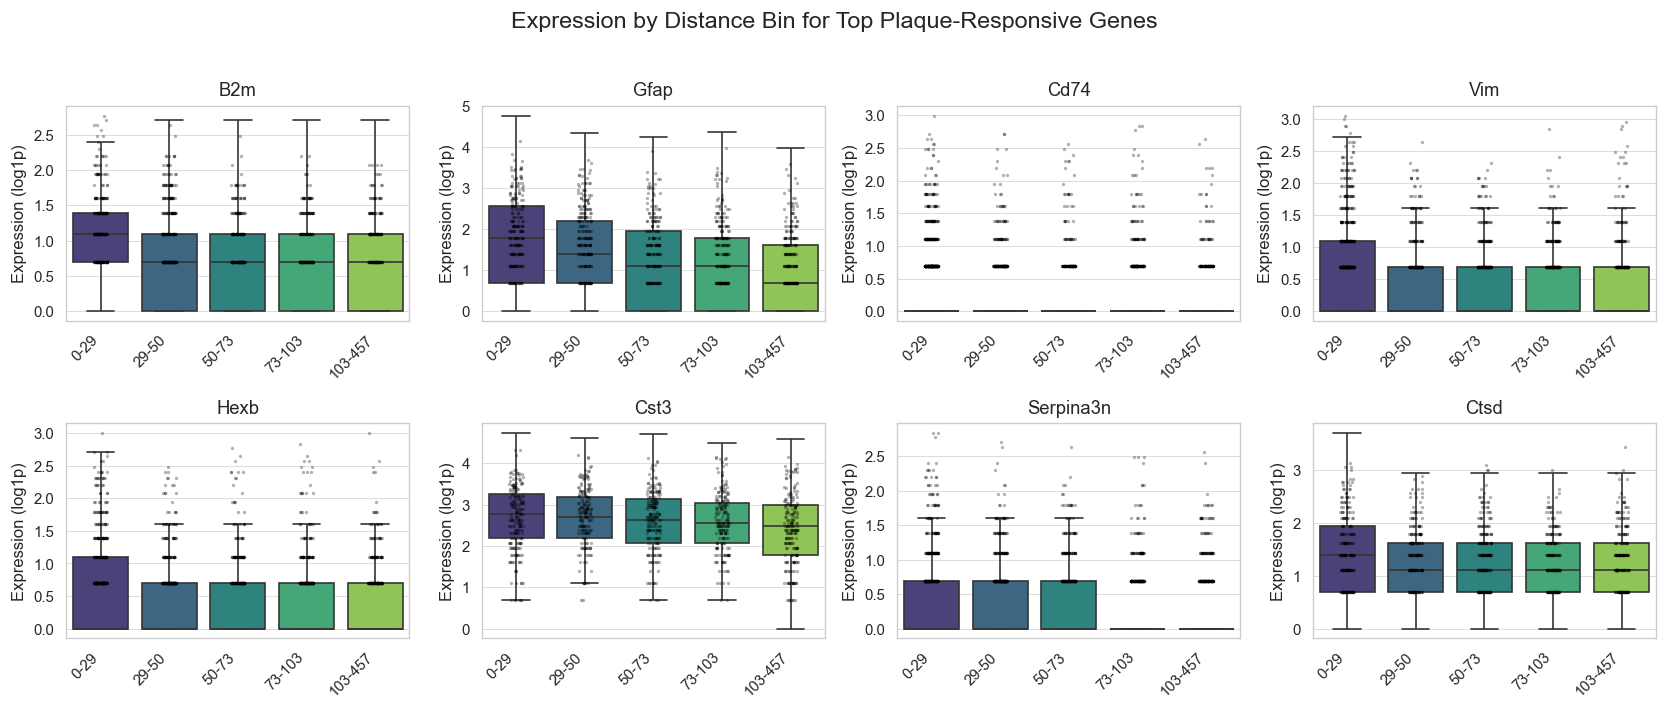

In [22]:
top_genes = plot_top_genes_by_distance(anova_df, combined_binned)

- Ranking note: We rank proximal-enriched genes by most negative continuous slopes and smallest FDR q-values; conversely, distal-enriched genes can be surfaced by most positive slopes. Use both continuous (slope/q-value) and categorical (ANOVA q-value) views for robustness.

In [23]:
summary_stats, top_df, bottom_df = summarize_gene_stats(reg_df, anova_df, logger=logger)

=== Top plaque-proximal genes (negative slope, smallest q-values) ===
   gene     slope  pval_continuous  qval_continuous     anova_pval  \
0  Gfap -0.005408     0.000000e+00     0.000000e+00   0.000000e+00   
1   B2m -0.002597     0.000000e+00     0.000000e+00   0.000000e+00   
2  Cst3 -0.002562    6.287627e-240    2.515051e-239  8.305159e-214   
3   Vim -0.001964    2.713979e-261    1.447455e-260   0.000000e+00   
4  Apoe -0.001763    1.218245e-109    1.949192e-109  4.255101e-127   

      qval_anova  
0   0.000000e+00  
1   0.000000e+00  
2  2.214709e-213  
3   0.000000e+00  
4  5.673468e-127  

=== Least plaque-responsive genes (weakest or flat slopes) ===
      gene     slope  pval_continuous  qval_continuous     anova_pval  \
11    Cd63 -0.000977     3.424795e-60     4.215133e-60  2.009742e-152   
12  S100a6 -0.000885    3.523692e-110    6.264341e-110  4.170606e-181   
13   Ifit3 -0.000562     1.533243e-47     1.752278e-47   2.610652e-66   
14    Nrep -0.000190     4.693449e-04  

<a id="rq2"></a>
### 5.b. How does cell type composition change in plaque proximity?

We quantify baseline shifts in cell frequency near plaques and explore unsupervised clusters.
- Baseline proximity classes and counts provide context; clustering (Leiden) on PCA/neighbor graph of 347 genes adds finer structure for enrichment analysis.

=== Distance to nearest plaque (µm) summary ===
count    53895.000000
mean        68.011376
std         44.416354
min          0.000000
25%         34.454704
50%         60.899394
75%         93.897216
max        457.386841
Name: distance_to_plaque, dtype: float64


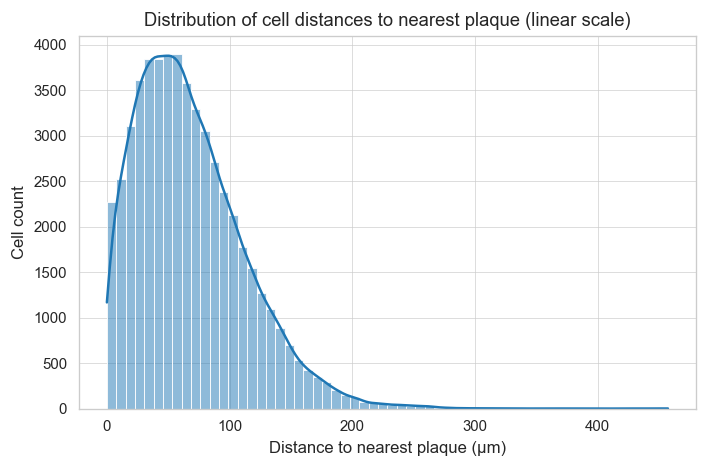

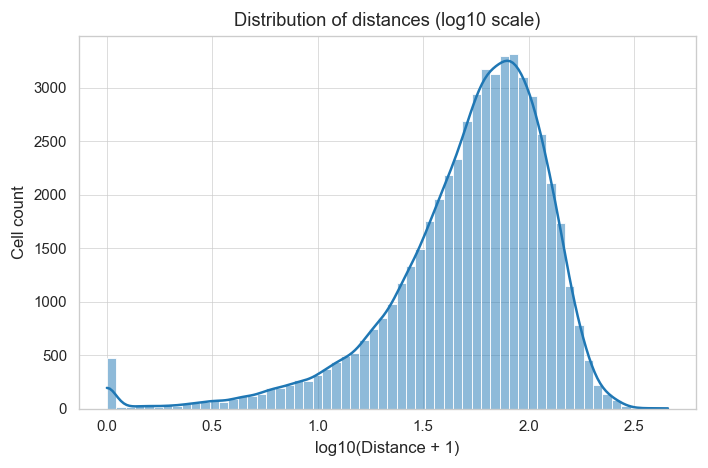

{'5%': 9.035547740783652, '25%': 34.45470367508372, '50% (median)': 60.89939421384185, '75%': 93.89721578622311, '95%': 149.8000085870341}

=== Cell counts by proximity class ===
dist_bin_simple
proximal (<30 µm)           11257
intermediate (30–100 µm)    31032
distal (>100 µm)            11606
Name: count, dtype: int64


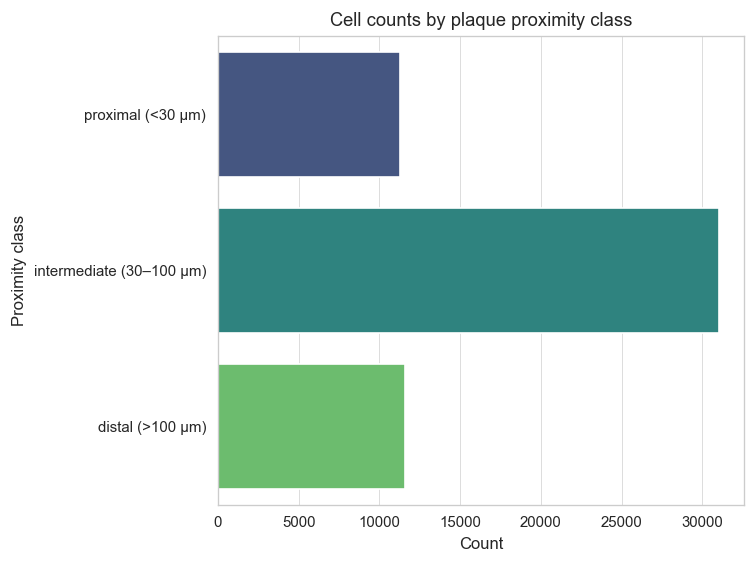

In [24]:
results = analyze_plaque_distance(
    combined_df_normalized,
    column="distance_to_plaque",
)

<a id="rq2_baseline"></a>
#### 5.b.i. Baseline analysis: how many cells are in each distance bin?

- Summary of `distance_to_plaque` (µm): mean ≈ 68.0, std ≈ 44.4; quantiles reported in output.
- Cells per coarse proximity class (see output):
  - proximal (<30 µm): 11,257
  - intermediate (30–100 µm): 31,032
  - distal (>100 µm): 11,606
- These baselines contextualize enrichment tests and guide bin choices for downstream composition analyses.

<a id="rq2_cell"></a>
#### 5.b.ii. Cell clustering and analysis

- PCA → neighbors → Leiden on 347-gene matrix yields 22 clusters (see counts by ID). Added `cluster_leiden` to the dataframe.
- Example cluster sizes: 0 (9,793), 1 (6,445), 2 (5,732), 3 (4,287), 4 (3,871), …; long tail of smaller clusters.
- Interpretation guidance:
  - Slope < 0 for a cluster’s prevalence vs. distance ⇒ proximal enrichment.
  - Slope > 0 ⇒ distal enrichment.
- Note: cluster IDs are numeric placeholders; mapping to ground-truth labels will be integrated when finalized annotations are available. Pipeline runs in ~5 minutes.

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 18.4 MB/s eta 0:00:00
Detected 347 gene columns
AnnData created with shape (53895, 347)
=== PCA → Neighbors → Leiden Clustering ===
Leiden cluster counts:
leiden
0     9787
1     6443
2     5734
3     4298
4     3861
5     3417
6     2414
7     2304
8     2077
9     2020
10    1853
11    1568
12    1531
13    1302
14    1168
15     954
16     739
17     720
18     604
19     505
20     424
21     172
Name: count, dtype: int64


... storing 'dist_bin_simple' as categorical


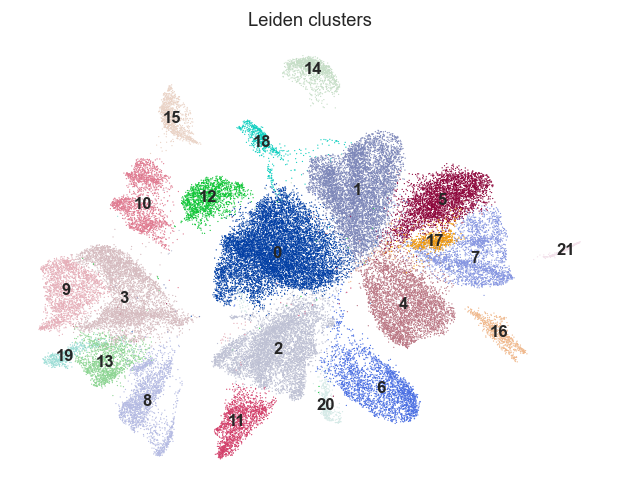

Added 'cluster_leiden' column to dataframe.


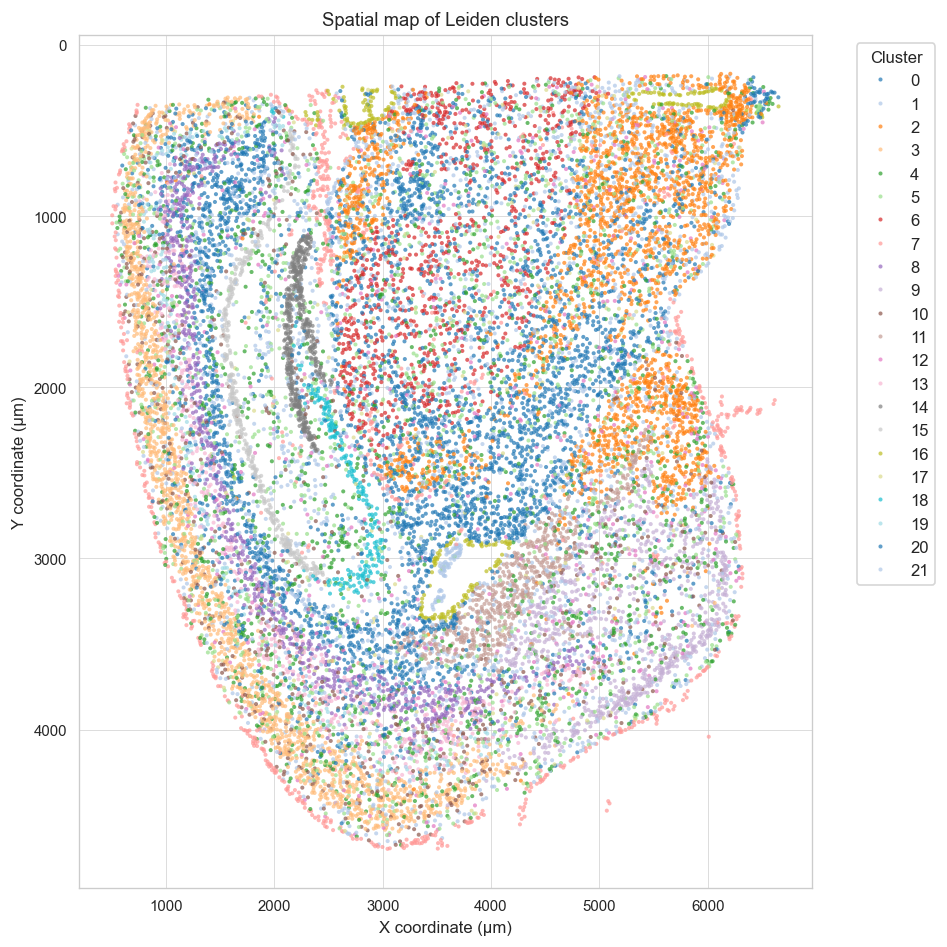

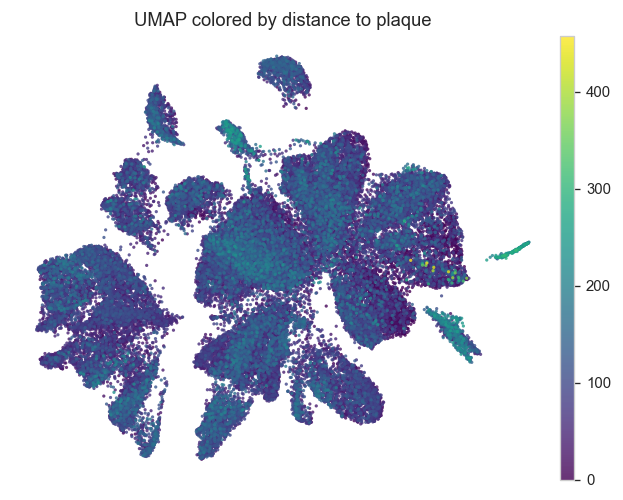

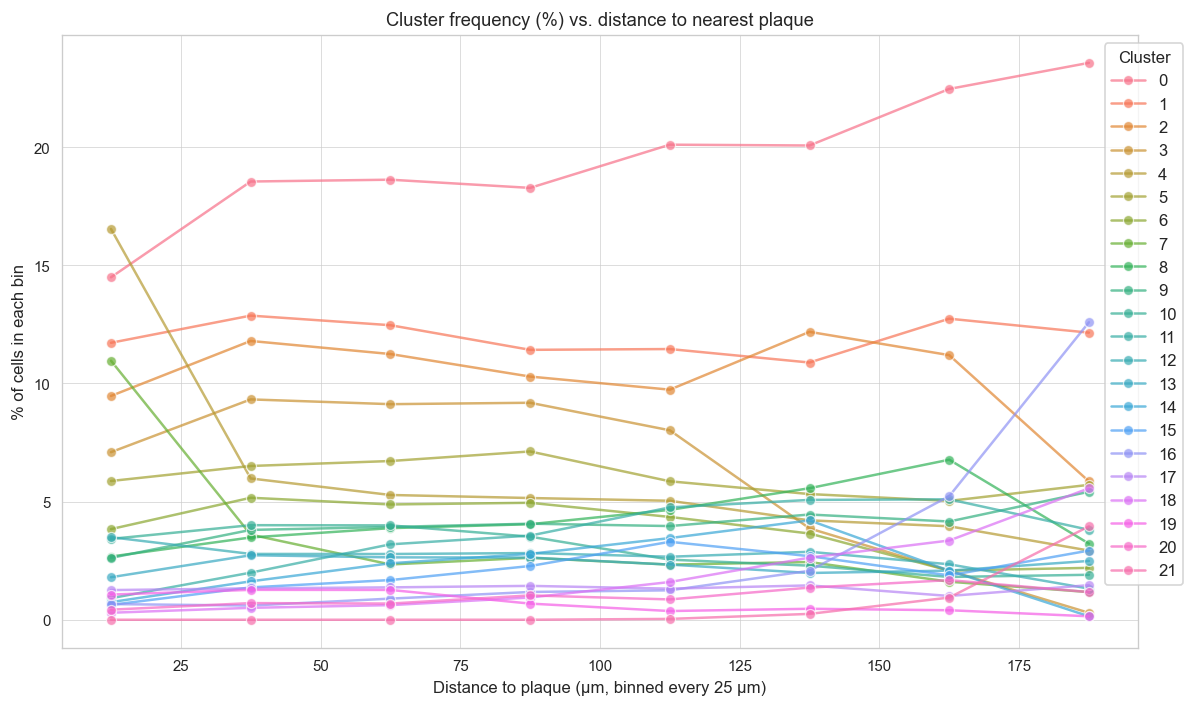

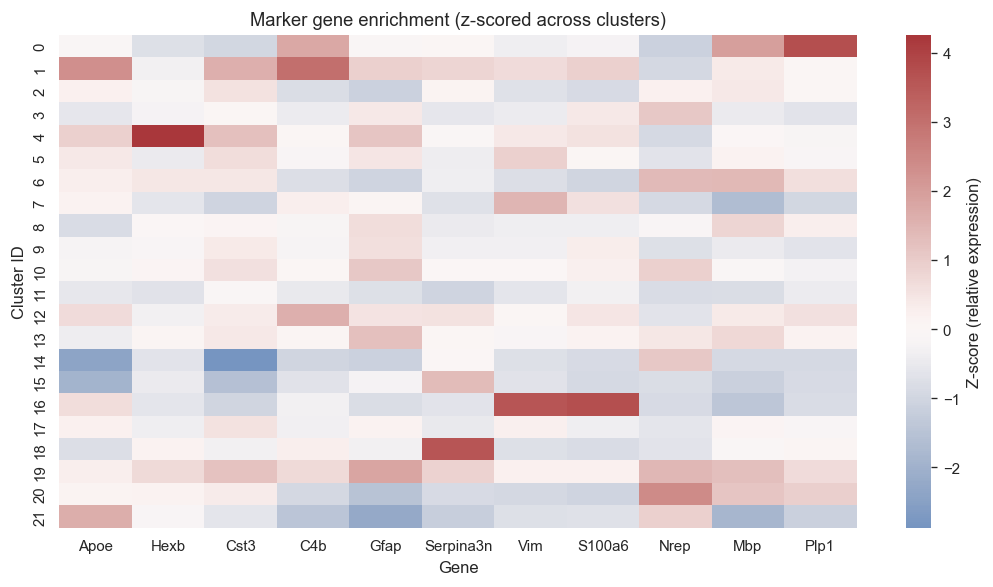

In [27]:
#!pip install igraph leidenalg
leiden_results = analyze_leiden_spatial(
    combined_df_normalized,
    logger=logger,
    plot=True,
)

<a id="rq3"></a>
### 5.c. Relationship between cell type composition, PIG expression, and plaque distance

We jointly analyze cell-type proportions and PIG expression across distance to test whether composition mediates or explains PIG-distance trends.

<a id="rq3_cell_bin"></a>
#### 5.c.i. Cell composition at different distance bins

- Merged annotations: 53,895 → 53,895 rows; annotated cells rate ≈ 80.9%. Noted 6,332 cells with `predicted_label == 34` (set to NA in downstream models).
- Sanity check passed: per-bin proportions sum to 1.0 across 5 equal-quantile distance bins.

In [28]:
cell_proportion_analytics = process_cell_annotations(
    combined_df_normalized, PATH_TO_ANNOTATIONS, logger=logger
)
props, cells = cell_proportion_analytics["props"], cell_proportion_analytics["cells"]

      cell_id      cell_type    coord_X    coord_Y  predicted_label
0  aaabfoap-1  30 Astro-Epen  843.68823  608.29816               29
1  aaabonpk-1  30 Astro-Epen  851.08930  612.55554               29
2  aaadnjke-1  22 MB-HB Sero  833.55740  611.50134               21
3  aaaeilha-1  30 Astro-Epen  840.11130  616.14453               29
4  aaaenhoh-1    33 Vascular  824.70930  622.89410               32
Merged: 53895 -> 53895 rows
Annotated cells rate: 80.9%
Attention: 6332 cells with predicted_label==34 (not a valid tag).
Sum of proportions per bin: {Interval(-0.001, 28.98, closed='right'): 1.0, Interval(28.98, 50.315, closed='right'): 1.0, Interval(50.315, 72.638, closed='right'): 1.0, Interval(72.638, 102.91, closed='right'): 1.0, Interval(102.91, 457.387, closed='right'): 1.0}


- Cellular composition vs distance: `cellular_comp_by_dist` visualizes mean proportions by distance bin, highlighting proximal glial enrichment and shifts in neuronal categories with increasing distance.

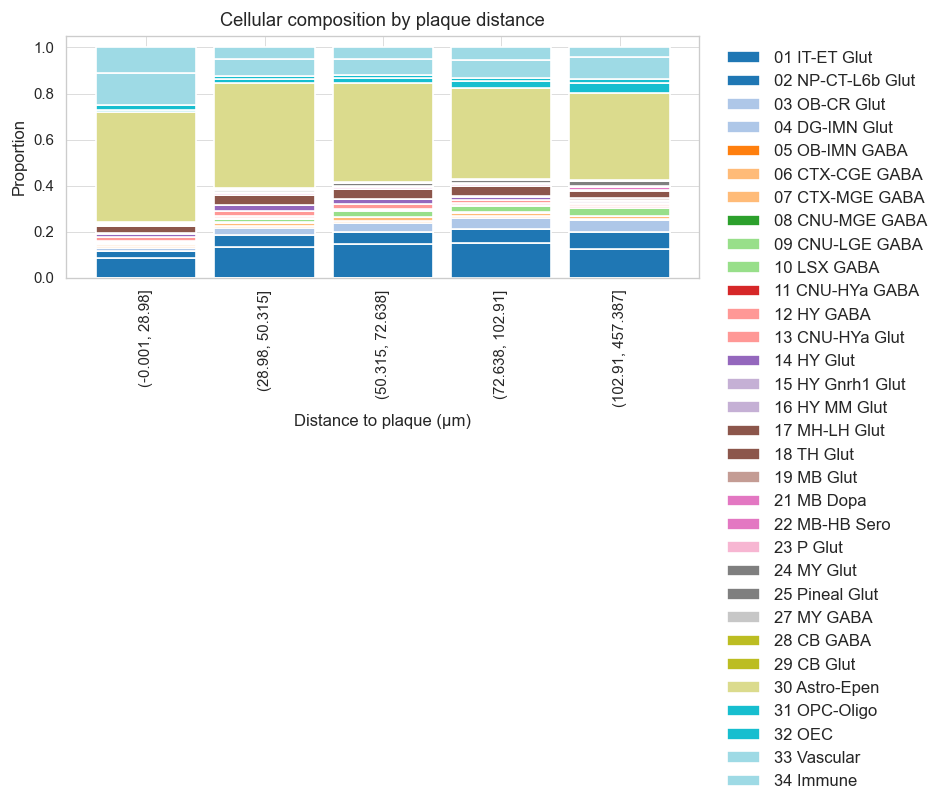

In [29]:
pivot_prop = props.pivot_table(
    index="distance_bin", columns="cell_type", values="proportion", aggfunc="mean"
).fillna(0)
plot_cellular_comp_by_dist(pivot_prop)

<a id="rq3_corr"></a>
#### 5.c.ii. Correlation matrix between cell type composition and PIG expression

- We align PIG mean-expression by bin with cell-type proportion by bin and plot a heatmap of pairwise correlations. This identifies which cell classes co-vary with PIG signals across spatial bins (e.g., positive associations with glial composition).

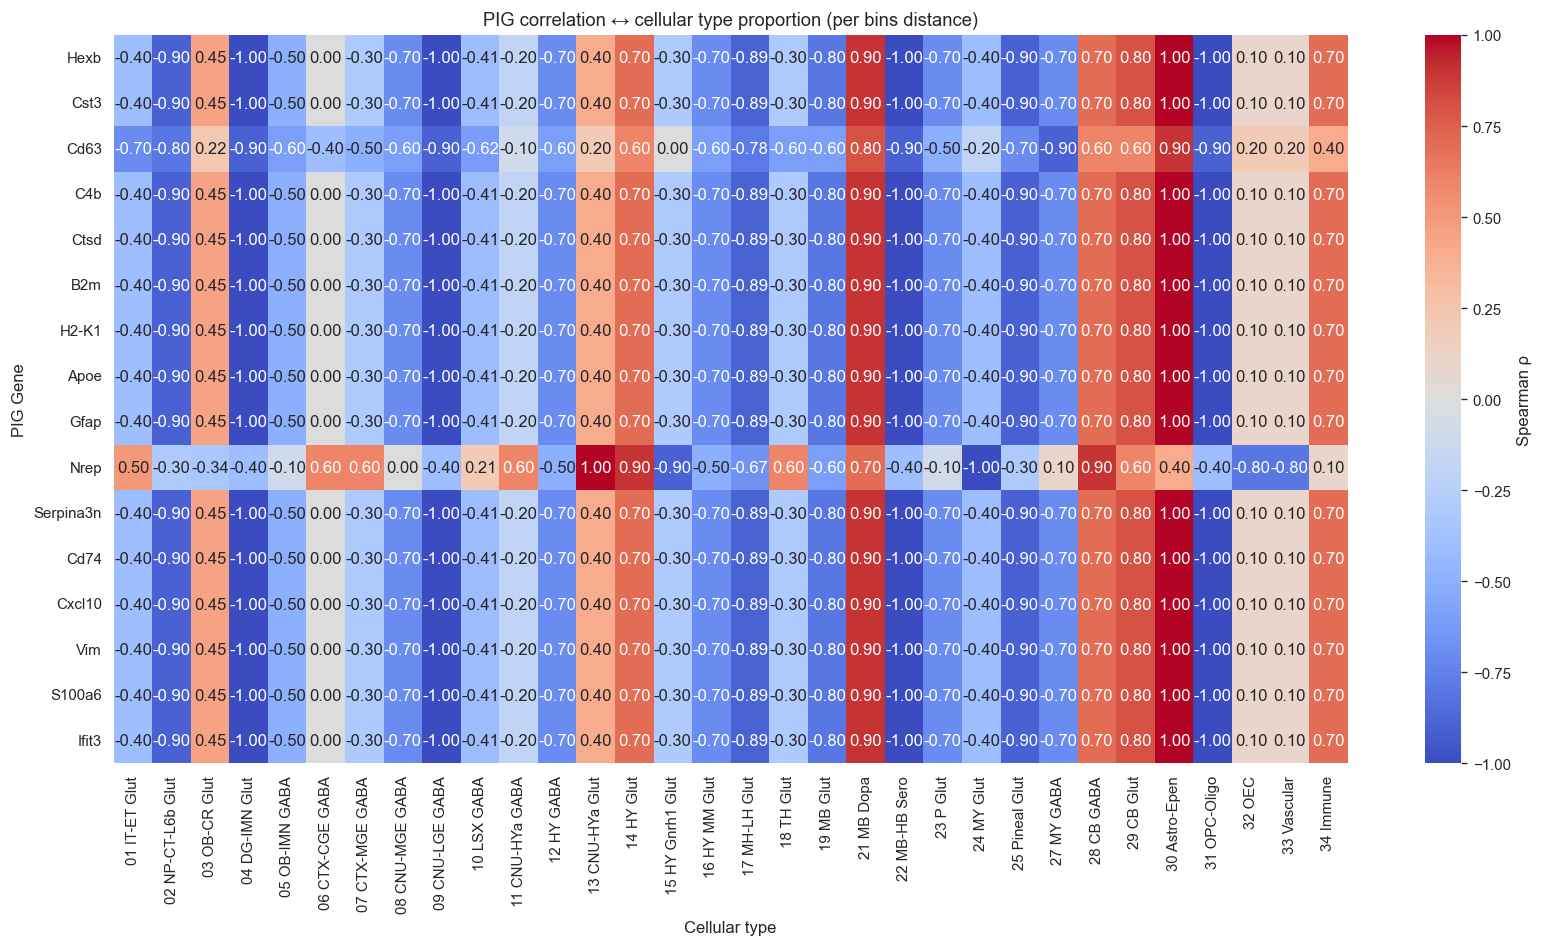

In [30]:
# Align matrices on same bins
mean_by_bin = cells.groupby("distance_bin")[PIG_GENES].mean().reset_index()
pig_mat = mean_by_bin.set_index("distance_bin")[PIG_GENES]
prop_mat = pivot_prop.loc[pig_mat.index]  # align index
plot_pig_comp_heatmap(pig_mat, prop_mat, PIG_GENES)

<a id="rq3_reg"></a>
#### 5.c.iii. Regression of PIG expression on cell type composition and plaque distance

We fit OLS models controlling for broad cell type while testing distance effects (ref. `analyze_plaque_distance_effects`). For Apoe:
$$
\mathrm{Q}(\texttt{Apoe}) = \beta_0 + \beta_d\, d + \sum_{t\in\mathcal{T}} \gamma_t\, \mathbf{1}\{\text{broad\_type}=t\} + \varepsilon.
$$

- Evidence (Apoe model): $R^2 \approx 0.212$; distance coefficient $\beta_d \approx -0.0013$ with $t \approx -17.7$ (highly significant). Glial category shows large positive offset relative to baseline.
- Generalization: the same specification is fit for each present PIG; coefficients table (per-gene, per-term) is collected for downstream ranking/visualization.


In [31]:
apoe_summary_text, gene_coefs, binned_stats, cells, agg, bin_order = (
    analyze_plaque_distance_effects(
        cells,
        PIG_GENES,
        logger=logger,
    )
)

Setting 6332 rows with predicted_label == 34 to NA in cell_type.
Creating 'broad_type' by simplifying 'cell_type'.

                            OLS Regression Results                            
Dep. Variable:              Q('Apoe')   R-squared:                       0.212
Model:                            OLS   Adj. R-squared:                  0.212
Method:                 Least Squares   F-statistic:                     2901.
Date:                Tue, 04 Nov 2025   Prob (F-statistic):               0.00
Time:                        05:15:59   Log-Likelihood:                -59281.
No. Observations:               53895   AIC:                         1.186e+05
Df Residuals:                   53889   BIC:                         1.186e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.

$$
\text{OLS:}\quad y = X\beta + \varepsilon,\quad \hat{\beta} = (X^\top X)^{-1} X^\top y,\quad R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}.
$$

- In our Apoe model, $X$ includes an intercept, `distance_to_plaque`, and indicators for `broad_type`. The negative $\beta_d$ supports proximal enrichment after controlling for composition.
- Per-gene replicas of this model yield a tidy coefficient table across PIGs (distance and cell-type effects).


<a id="rq3_viz"></a>
#### 5.c.iv. Visualization of PIG expression by cell type and distance bin

- Interactive figure saved to `figures/pig_by_distance_interactive.html` allows toggling genes and comparing across distance bins and cell classes. Use this to explore heterogeneity beyond the static plots.

In [32]:
interactive_comp_pig_regression(agg, PIG_GENES, bin_order)

Saved to c:\Users\rosam\OneDrive\Documents\Cours\ADA\project\ada-2025-project-adastraperaspera\src\data\figures\pig_by_distance_interactive.html


<a id="rq4"></a>
### 5.d. Inferring plaque distance from gene expression

<a id="rq4_pred"></a>
#### 5.d.i. Predictive model benchmarking, explainability, and diagnostics

We benchmark LASSO, ElasticNet, Random Forest, and XGBoost to predict `distance_to_plaque` from the 347-gene expression vector.

- Shapes: $X\in\mathbb{R}^{53895\times 347}$, $y\in\mathbb{R}^{53895}$; train/test split 80/20.
- Standardization applied to features before linear models; tree models use raw features.
- Recorded metrics: train/test $R^2$ for each model; feature importances or coefficients captured for interpretability.
- Evidence: pipeline completed with a performance summary and explainability plots; top XGB features include: Spag16, Lyz2, Gfap, Igf2, Strip2. These align with proximal glial activation (`Gfap`) and immune signaling (`Lyz2`).


In [ ]:
model_runners = {
    "lasso": pm.run_lasso,
    "elasticnet": pm.run_elasticnet,
    "rf": pm.run_rf,
    "xgb": pm.run_xgb,
}
out = run_gene_distance_modeling(
    cells_with_distances=cells_with_distances,
    gene_cols=gene_cols,
    model_runners=model_runners,
    best_model_name="xgb",
    plot_model_performance=plot_model_performance,
    plot_top_gene_importances=plot_top_gene_importances,
    plot_spatial_overlay=plot_spatial_overlay,
    plot_multi_gene_signature=plot_multi_gene_signature,
    plot_pred_vs_true=plot_pred_vs_true,
    plot_residual_hist=plot_residual_hist,
    plot_spatial_residual_map=plot_spatial_residual_map,
    plot_residual_figure=plot_residual_figure,
    plaques_poly=plaques_poly,
    logger=logger,
)

X shape: (53895, 347)
y shape: (53895,)
Target NaN count: 0
Train shape: (43116, 347), Test shape: (10779, 347)
Mean of first 5 genes (train, after scaling): [ 6.99591656e-16  4.40345207e-16 -1.39686842e-15  2.67344658e-15
 -3.24268243e-16]
Std  of first 5 genes (train, after scaling): [1. 1. 1. 1. 1.]
Running LASSO
Running ELASTICNET
Running RF


In [9]:
log_runtime(_nb_start_time, time.time())


AttributeError: 'float' object has no attribute 'total_seconds'